In [ ]:
!pip install opencv-python scikit-image matplotlib pandas numpy

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import os
import glob
import random
import time
from collections import Counter, defaultdict
from skimage.feature import hog, local_binary_pattern

# Reproducibility
np.random.seed(42)
random.seed(42)

print('✅ All libraries imported successfully!')
print(f'   NumPy     : {np.__version__}')
print(f'   Pandas    : {pd.__version__}')
print(f'   OpenCV    : {cv2.__version__}')

✅ All libraries imported successfully!
   NumPy     : 2.0.2
   Pandas    : 2.2.2
   OpenCV    : 4.13.0


In [ ]:
# ── Cell 1.3: Dataset Setup (Manual Upload Method) ────────────────────────────
import os
import zipfile
from google.colab import files

print("📤 Please select your DATASET file to upload (.zip or .rar)")
print("   e.g. 'dataset-resized.zip' — the TrashNet dataset with one folder per class\n")

uploaded = files.upload()          # opens a file picker — choose your dataset archive

dataset_filename = list(uploaded.keys())[0]   # name of the file you just uploaded
extract_path = '/content/'

print(f"\n⏳ Extracting '{dataset_filename}'...")

if dataset_filename.lower().endswith('.zip'):
    with zipfile.ZipFile(dataset_filename, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("✅ ZIP extraction complete.")

elif dataset_filename.lower().endswith('.rar'):
    # unrar is not installed by default in Colab — install it first
    !apt-get install -y unrar > /dev/null 2>&1
    !unrar x -Y "{dataset_filename}" "{extract_path}" > /dev/null
    print("✅ RAR extraction complete.")

else:
    print(f"⚠️  Unsupported file type: '{dataset_filename}'. Please upload a .zip or .rar file.")

# ── Auto-detect the folder that actually contains the class subfolders ──
CLASS_NAMES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
DATA_DIR = None

for root, dirs, _ in os.walk(extract_path):
    if any(c in dirs for c in CLASS_NAMES):
        DATA_DIR = root
        break

if DATA_DIR:
    found_classes = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
    print(f'\n✅ Dataset successfully extracted!')
    print(f'📂 Data directory located at: {DATA_DIR}')
    print(f'📋 Classes found: {found_classes}')
else:
    print('\n❌ Error: Could not locate class folders after extraction.')
    print('   Check that your archive contains folders named:', CLASS_NAMES)

📤 Please select your DATASET file to upload (.zip or .rar)
   e.g. 'dataset-resized.zip' — the TrashNet dataset with one folder per class



Saving archive.zip to archive.zip

⏳ Extracting 'archive.zip'...
✅ ZIP extraction complete.

✅ Dataset successfully extracted!
📂 Data directory located at: /content/dataset-resized
📋 Classes found: ['trash', 'glass', 'paper', 'cardboard', 'plastic', 'metal']


---
## 📊 PART 2 — Exploratory Data Analysis (EDA)

Before training any model, we must **understand the data** deeply.

We will explore:
- Class distribution (how many images per class)
- Image dimensions
- Sample images per class
- RGB channel histograms
- Pixel intensity distributions
- Duplicate and missing value checks
- Class imbalance analysis

In [ ]:
# ── Cell 2.1: Count Images Per Class ─────────────────────────────────────────
if DATA_DIR is None:
    raise ValueError(
        "DATA_DIR is None — Cell 1.3 could not find your class folders. "
        "Fix the dataset extraction before running this cell."
    )

class_image_counts = {}
all_image_paths    = []
all_labels         = []

# Map CLASS_NAMES to whatever the actual folder names are (case-insensitive match)
existing_dirs = {d.lower(): d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))}

for cls in CLASS_NAMES:
    actual_folder = existing_dirs.get(cls.lower())
    if actual_folder is None:
        print(f'⚠️  Folder not found for class: {cls}')
        class_image_counts[cls] = 0
        continue

    cls_path = os.path.join(DATA_DIR, actual_folder)
    imgs = (glob.glob(os.path.join(cls_path, '*.jpg'))  + glob.glob(os.path.join(cls_path, '*.JPG'))  +
            glob.glob(os.path.join(cls_path, '*.jpeg')) + glob.glob(os.path.join(cls_path, '*.JPEG')) +
            glob.glob(os.path.join(cls_path, '*.png'))  + glob.glob(os.path.join(cls_path, '*.PNG')))

    class_image_counts[cls] = len(imgs)
    all_image_paths.extend(imgs)
    all_labels.extend([cls] * len(imgs))

total_images = sum(class_image_counts.values())

print('=' * 45)
print(f'  TrashNet Dataset — Summary')
print('=' * 45)
print(f'  Total images : {total_images}')
print(f'  Total classes: {len(CLASS_NAMES)}')
print('-' * 45)

if total_images == 0:
    print('  ⚠️  No images found in any class folder — check DATA_DIR contents:')
    print('     ', os.listdir(DATA_DIR))
else:
    for cls, cnt in class_image_counts.items():
        pct = cnt / total_images * 100
        bar = '█' * int(pct / 2)
        print(f'  {cls:<12}: {cnt:>4} images  ({pct:.1f}%)  {bar}')
print('=' * 45)

  TrashNet Dataset — Summary
  Total images : 2527
  Total classes: 6
---------------------------------------------
  cardboard   :  403 images  (15.9%)  ███████
  glass       :  501 images  (19.8%)  █████████
  metal       :  410 images  (16.2%)  ████████
  paper       :  594 images  (23.5%)  ███████████
  plastic     :  482 images  (19.1%)  █████████
  trash       :  137 images  (5.4%)  ██


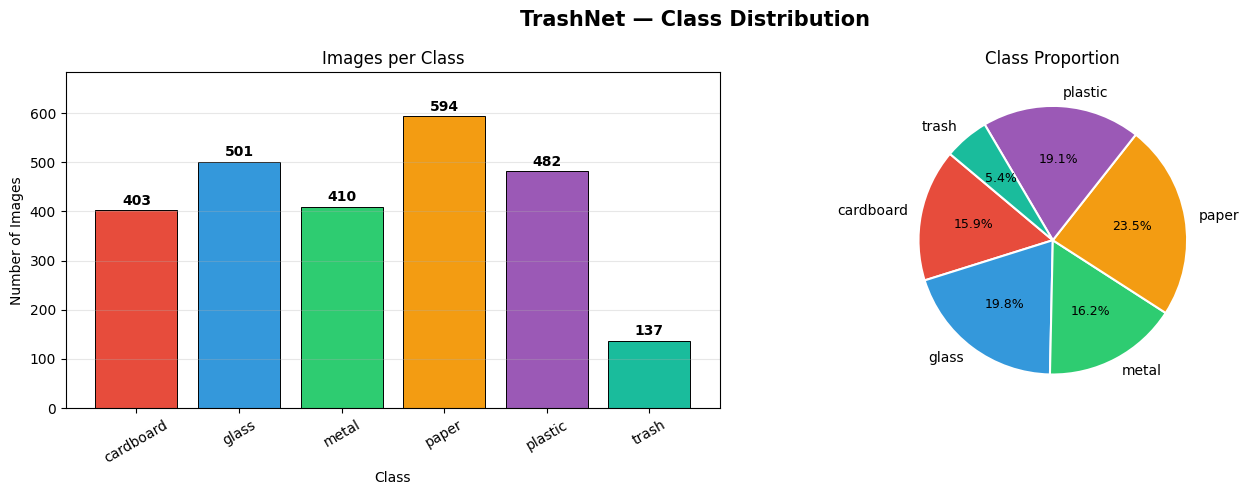

✅ Class distribution chart saved.


In [ ]:
# ── Cell 2.2: Class Distribution Bar Chart ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('TrashNet — Class Distribution', fontsize=15, fontweight='bold')

colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c']

# Bar chart
bars = axes[0].bar(CLASS_NAMES,
                   [class_image_counts[c] for c in CLASS_NAMES],
                   color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('Images per Class')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Images')
axes[0].set_ylim(0, max(class_image_counts.values()) * 1.15)
for bar, cnt in zip(bars, [class_image_counts[c] for c in CLASS_NAMES]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5, str(cnt),
                 ha='center', va='bottom', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    [class_image_counts[c] for c in CLASS_NAMES],
    labels=CLASS_NAMES,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
axes[1].set_title('Class Proportion')
for at in autotexts:
    at.set_fontsize(9)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Class distribution chart saved.')

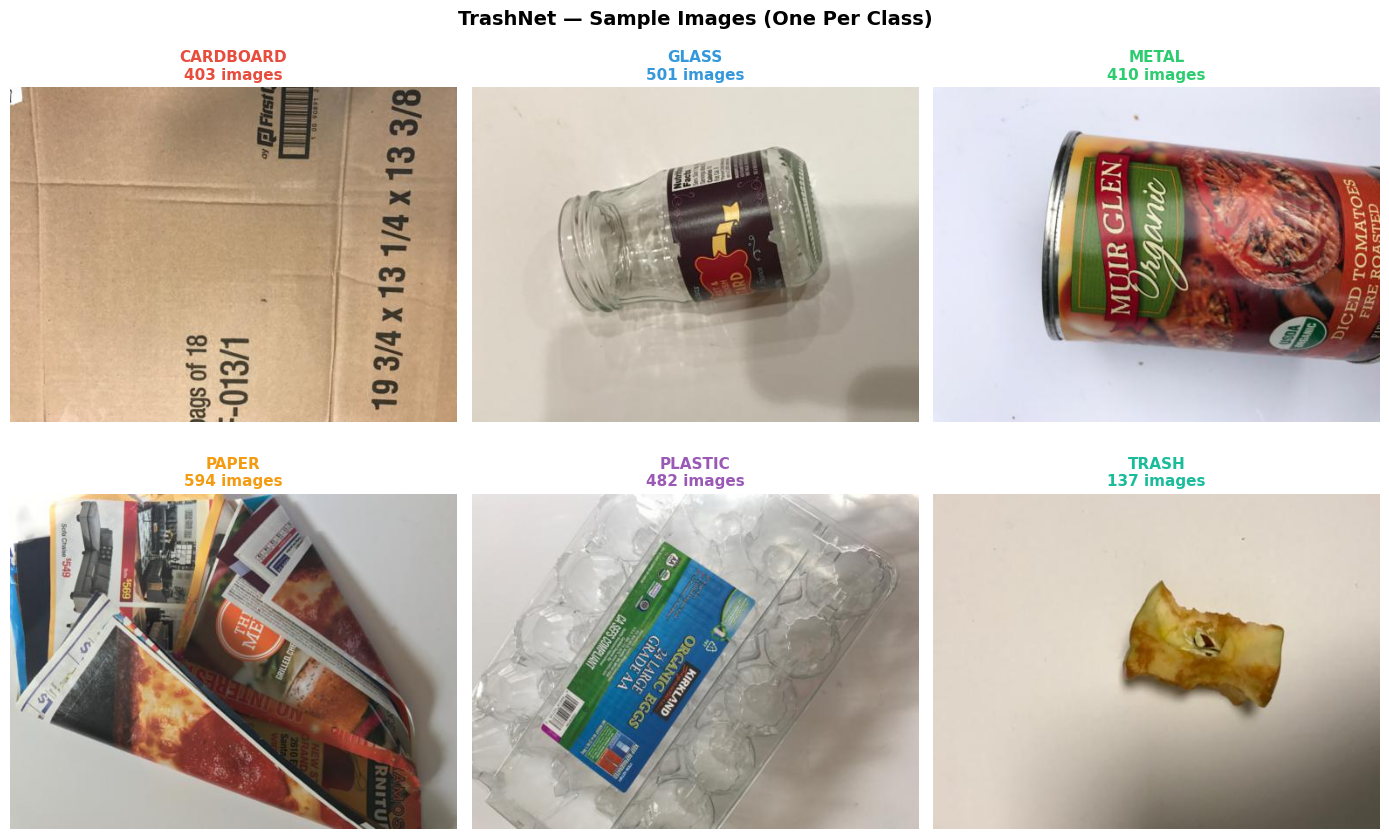

✅ Sample images displayed.


In [ ]:
# ── Cell 2.3: Sample Images Per Class ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle('TrashNet — Sample Images (One Per Class)', fontsize=14, fontweight='bold')

for ax, cls, color in zip(axes.flat, CLASS_NAMES, colors):
    cls_path = os.path.join(DATA_DIR, cls)
    imgs = glob.glob(os.path.join(cls_path, '*.jpg')) + \
           glob.glob(os.path.join(cls_path, '*.jpeg')) + \
           glob.glob(os.path.join(cls_path, '*.png'))
    if not imgs:
        ax.set_visible(False)
        continue
    img_path = random.choice(imgs)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f'{cls.upper()}\n{class_image_counts[cls]} images',
                 fontweight='bold', color=color, fontsize=11)
    ax.axis('off')
    # Colored border
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sample images displayed.')

Image Dimension Statistics (sample of 300):
  Width  — min:512, max:512, mean:512
  Height — min:384, max:384, mean:384


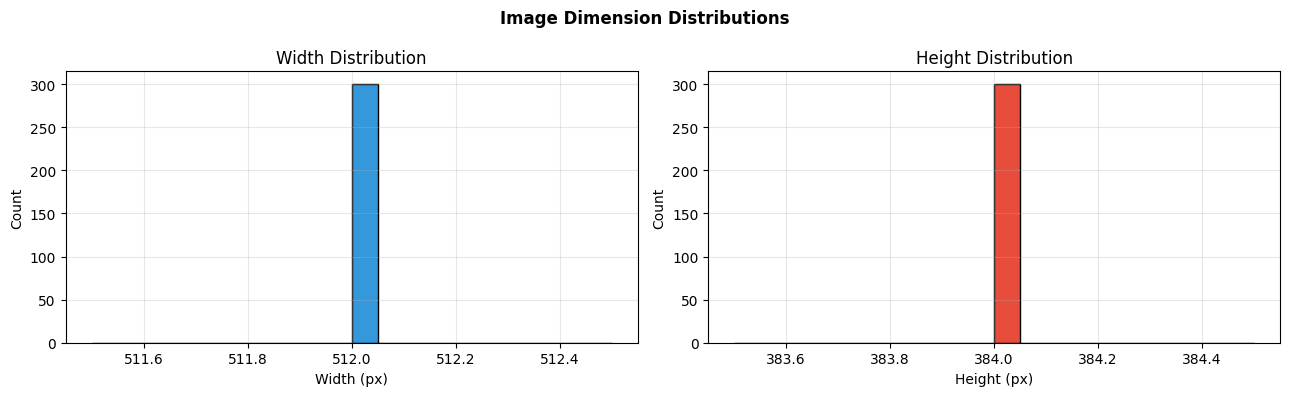

In [ ]:
# ── Cell 2.4: Image Dimensions Analysis ───────────────────────────────────────
sample_paths = random.sample(all_image_paths, min(300, len(all_image_paths)))
widths, heights = [], []

for p in sample_paths:
    img = cv2.imread(p)
    if img is not None:
        h, w = img.shape[:2]
        heights.append(h)
        widths.append(w)

print('Image Dimension Statistics (sample of 300):')
print(f'  Width  — min:{min(widths)}, max:{max(widths)}, mean:{np.mean(widths):.0f}')
print(f'  Height — min:{min(heights)}, max:{max(heights)}, mean:{np.mean(heights):.0f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(widths,  bins=20, color='#3498db', edgecolor='black')
axes[0].set_title('Width Distribution');  axes[0].set_xlabel('Width (px)')
axes[1].hist(heights, bins=20, color='#e74c3c', edgecolor='black')
axes[1].set_title('Height Distribution'); axes[1].set_xlabel('Height (px)')
for ax in axes:
    ax.set_ylabel('Count'); ax.grid(alpha=0.3)
plt.suptitle('Image Dimension Distributions', fontweight='bold')
plt.tight_layout()
plt.savefig('dimensions.png', dpi=150, bbox_inches='tight')
plt.show()

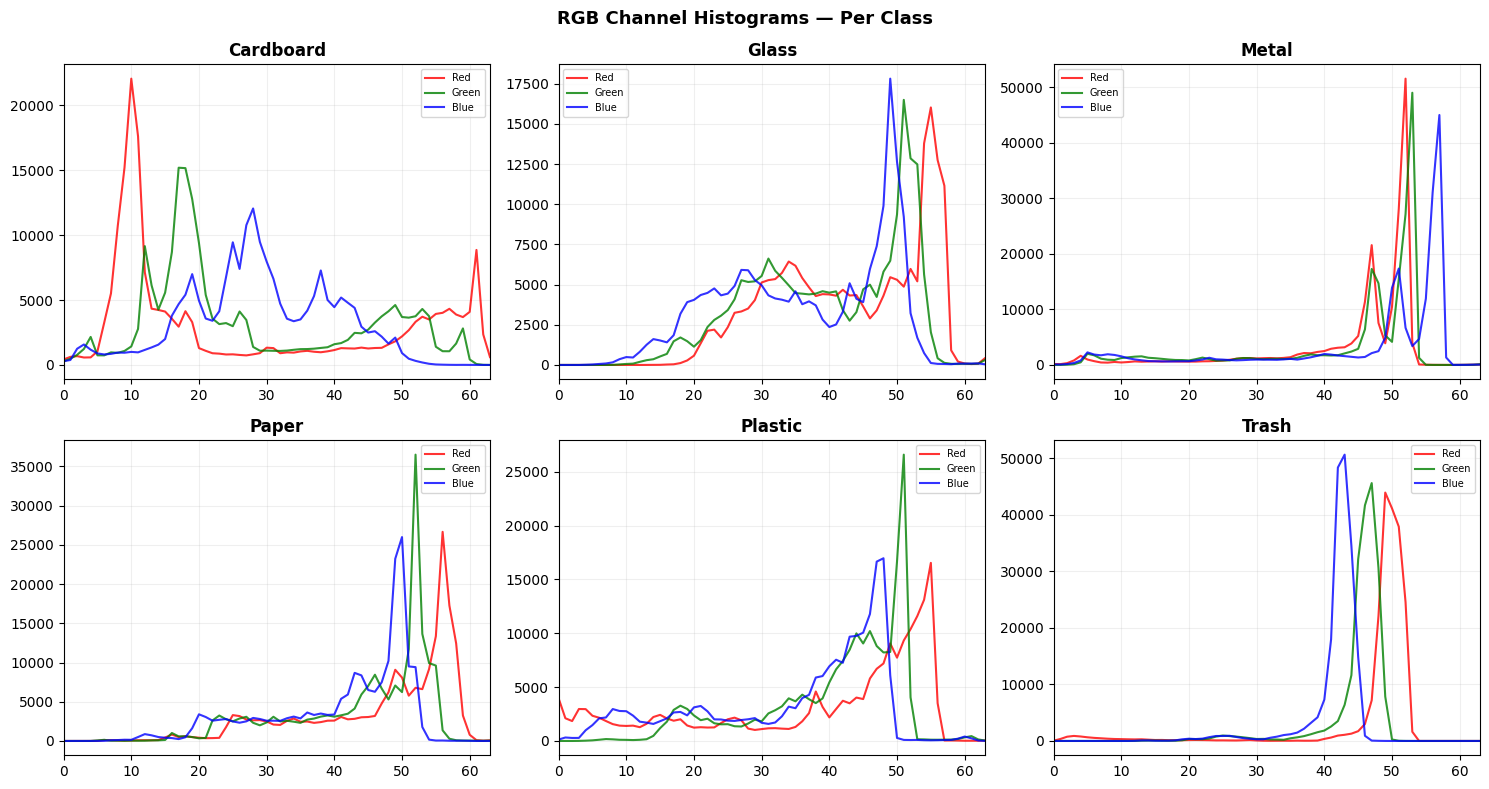

✅ RGB histograms plotted.


In [ ]:
# ── Cell 2.5: RGB Channel Histogram ───────────────────────────────────────────
# Sample one image per class for RGB analysis
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('RGB Channel Histograms — Per Class', fontsize=13, fontweight='bold')
channel_colors = ('r', 'g', 'b')
channel_names  = ('Red', 'Green', 'Blue')

for ax, cls in zip(axes.flat, CLASS_NAMES):
    cls_path = os.path.join(DATA_DIR, cls)
    imgs = glob.glob(os.path.join(cls_path, '*.jpg')) + \
           glob.glob(os.path.join(cls_path, '*.jpeg')) + \
           glob.glob(os.path.join(cls_path, '*.png'))
    img = cv2.imread(random.choice(imgs))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    for ch, col, name in zip(range(3), channel_colors, channel_names):
        hist = np.histogram(img_rgb[:,:,ch].ravel(), bins=64, range=(0,256))[0]
        ax.plot(hist, color=col, label=name, alpha=0.8, linewidth=1.5)
    ax.set_title(f'{cls.capitalize()}', fontweight='bold')
    ax.set_xlim(0, 63); ax.grid(alpha=0.2)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('rgb_histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ RGB histograms plotted.')

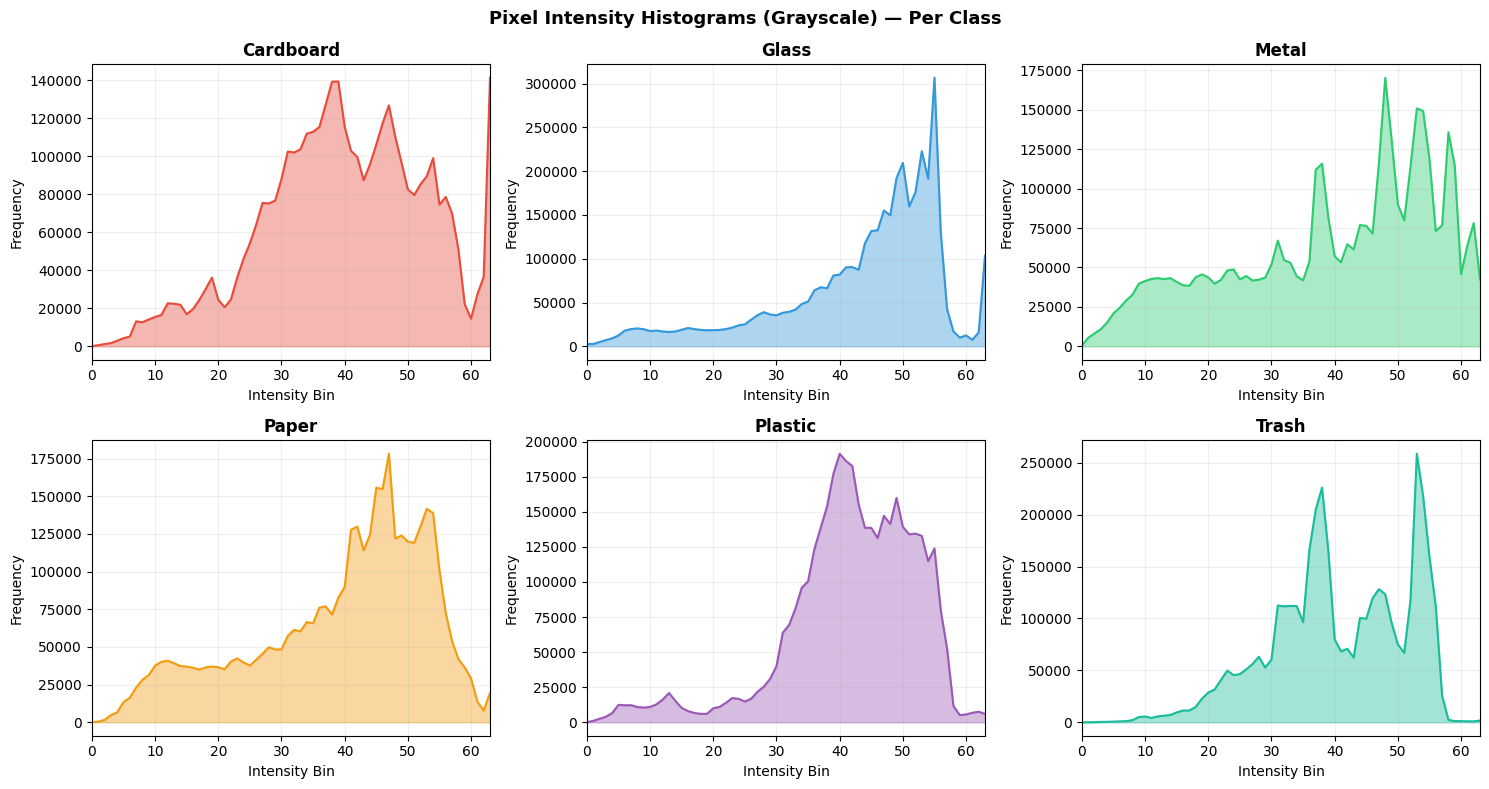

In [ ]:
# ── Cell 2.6: Pixel Intensity Histogram (Grayscale) ───────────────────────────
# Aggregate pixel intensities across all classes
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Pixel Intensity Histograms (Grayscale) — Per Class',
             fontsize=13, fontweight='bold')

for ax, cls, color in zip(axes.flat, CLASS_NAMES, colors):
    cls_path = os.path.join(DATA_DIR, cls)
    imgs = glob.glob(os.path.join(cls_path, '*.jpg')) + \
           glob.glob(os.path.join(cls_path, '*.jpeg')) + \
           glob.glob(os.path.join(cls_path, '*.png'))
    sample = random.sample(imgs, min(20, len(imgs)))
    agg_hist = np.zeros(64)
    for p in sample:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            h = np.histogram(img.ravel(), bins=64, range=(0,256))[0]
            agg_hist += h
    ax.fill_between(range(64), agg_hist, alpha=0.4, color=color)
    ax.plot(agg_hist, color=color, linewidth=1.5)
    ax.set_title(f'{cls.capitalize()}', fontweight='bold')
    ax.set_xlim(0,63); ax.grid(alpha=0.2)
    ax.set_xlabel('Intensity Bin'); ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('intensity_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Cell 2.7: Duplicate & Missing Value Check ──────────────────────────────────
print('🔍 Checking for missing/corrupt images...')
corrupt = []
file_sizes = []

for p in all_image_paths:
    img = cv2.imread(p)
    if img is None:
        corrupt.append(p)
    else:
        file_sizes.append(os.path.getsize(p))

print(f'  ✅ Total images    : {len(all_image_paths)}')
print(f'  ❌ Corrupt/Missing : {len(corrupt)}')

# Duplicate check via file sizes (approximate)
size_counter = Counter(file_sizes)
duplicates   = {sz: cnt for sz, cnt in size_counter.items() if cnt > 1}
print(f'  ⚠️  Possible duplicate file sizes: {len(duplicates)} groups')
print(f'  📁 File size range: {min(file_sizes)//1024} KB – {max(file_sizes)//1024} KB')
print('\n✅ EDA complete. Dataset looks clean.')

🔍 Checking for missing/corrupt images...
  ✅ Total images    : 2527
  ❌ Corrupt/Missing : 0
  ⚠️  Possible duplicate file sizes: 139 groups
  📁 File size range: 5 KB – 56 KB

✅ EDA complete. Dataset looks clean.


In [ ]:
# ── Cell 2.8: Data Cleaning — Remove Corrupt, Duplicate & Blurry Images ───────
# Cell 2.7 only CHECKED for issues. This cell actually REMOVES them so training
# happens on a cleaner dataset:
#   1. Corrupt / unreadable images
#   2. Exact duplicates (MD5 hash of file bytes)
#   3. Near-duplicates (perceptual average-hash, compared within each class)
#   4. Extreme blur outliers (Laplacian variance, bottom 2% PER CLASS)

import hashlib

def compute_avg_hash(gray_img, hash_size=8):
    resized = cv2.resize(gray_img, (hash_size, hash_size))
    avg = resized.mean()
    bits = (resized > avg).flatten()
    return ''.join('1' if b else '0' for b in bits)

def hamming_distance(h1, h2):
    return sum(c1 != c2 for c1, c2 in zip(h1, h2))

print('🧹 Cleaning dataset...')
print(f'   Starting with {len(all_image_paths)} images\n')

records = []
for path, label in zip(all_image_paths, all_labels):
    with open(path, 'rb') as f:
        file_bytes = f.read()
    md5 = hashlib.md5(file_bytes).hexdigest()

    img = cv2.imread(path)
    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    ahash = compute_avg_hash(gray)
    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()

    records.append({'path': path, 'label': label, 'md5': md5,
                     'ahash': ahash, 'blur': blur_score})

n_corrupt = len(all_image_paths) - len(records)
print(f'   ❌ Corrupt/unreadable removed : {n_corrupt}')

seen_md5 = set()
after_exact = []
for r in records:
    if r['md5'] in seen_md5:
        continue
    seen_md5.add(r['md5'])
    after_exact.append(r)

n_exact_dup = len(records) - len(after_exact)
print(f'   🔁 Exact duplicates removed   : {n_exact_dup}')

by_class = defaultdict(list)
for r in after_exact:
    by_class[r['label']].append(r)

after_near_dup = []
NEAR_DUP_THRESHOLD = 3

for cls, items in by_class.items():
    kept_hashes = []
    for r in items:
        is_dup = any(hamming_distance(r['ahash'], kh) <= NEAR_DUP_THRESHOLD for kh in kept_hashes)
        if not is_dup:
            kept_hashes.append(r['ahash'])
            after_near_dup.append(r)

n_near_dup = len(after_exact) - len(after_near_dup)
print(f'   🔁 Near-duplicates removed    : {n_near_dup}')

by_class = defaultdict(list)
for r in after_near_dup:
    by_class[r['label']].append(r)

final_records = []
n_blurry = 0
for cls, items in by_class.items():
    blur_scores = np.array([r['blur'] for r in items])
    threshold = np.percentile(blur_scores, 2)
    for r in items:
        if r['blur'] < threshold:
            n_blurry += 1
            continue
        final_records.append(r)

print(f'   🌫️  Extreme blur outliers removed: {n_blurry}  (bottom 2% per class)')

all_image_paths = [r['path'] for r in final_records]
all_labels      = [r['label'] for r in final_records]

print(f'\n✅ Cleaning complete.')
print(f'   Before: {n_corrupt + n_exact_dup + n_near_dup + n_blurry + len(final_records)} images')
print(f'   After : {len(all_image_paths)} images')
print(f'   Removed: {n_corrupt} corrupt, {n_exact_dup} exact dup, {n_near_dup} near-dup, {n_blurry} blurry\n')

clean_counts = Counter(all_labels)
print('Class distribution after cleaning:')
for cls in CLASS_NAMES:
    print(f'   {cls:<12}: {clean_counts.get(cls, 0)}')


🧹 Cleaning dataset...
   Starting with 2527 images

   ❌ Corrupt/unreadable removed : 0
   🔁 Exact duplicates removed   : 3
   🔁 Near-duplicates removed    : 107
   🌫️  Extreme blur outliers removed: 51  (bottom 2% per class)

✅ Cleaning complete.
   Before: 2527 images
   After : 2366 images
   Removed: 0 corrupt, 3 exact dup, 107 near-dup, 51 blurry

Class distribution after cleaning:
   cardboard   : 387
   glass       : 473
   metal       : 386
   paper       : 542
   plastic     : 449
   trash       : 129


---
## 🖼️ PART 3 — Image Preprocessing

### Why Preprocess?
Raw images are of varying sizes, lighting conditions, and noise levels. Before extracting features, we must:

| Step | Reason |
|------|--------|
| **Resize to 128×128** | Makes all feature vectors the same length |
| **Convert to Grayscale** | Reduces dimensionality; HOG/LBP work on grayscale |
| **Normalize [0,1]** | Prevents large pixel values dominating distance metrics |
| **Gaussian Blur** | Reduces high-frequency noise |

We display **before/after** comparisons for each step.

In [ ]:
# ── Cell 3.1: Preprocessing Functions ────────────────────────────────────────
IMG_SIZE = (128, 128)  # Resize target

def load_and_resize(path):
    """Load image and resize to IMG_SIZE."""
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
    return img

def to_grayscale(img_rgb):
    """Convert RGB image to grayscale."""
    return cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

def normalize(img):
    """Normalize pixel values to [0, 1]."""
    return img.astype(np.float32) / 255.0

def remove_noise(img_gray):
    """Apply Gaussian blur for noise reduction."""
    return cv2.GaussianBlur(img_gray, (3, 3), 0)

def preprocess(path):
    """
    Full preprocessing pipeline:
      1. Load & resize
      2. Grayscale conversion
      3. Noise removal
      4. Normalization
    Returns (rgb_for_display, gray_normalized)
    """
    rgb   = load_and_resize(path)
    gray  = to_grayscale(rgb)
    denoised = remove_noise(gray)
    norm  = normalize(denoised)
    return rgb, norm

print('✅ Preprocessing functions defined.')
print(f'   Target image size: {IMG_SIZE[0]} × {IMG_SIZE[1]} pixels')

✅ Preprocessing functions defined.
   Target image size: 128 × 128 pixels


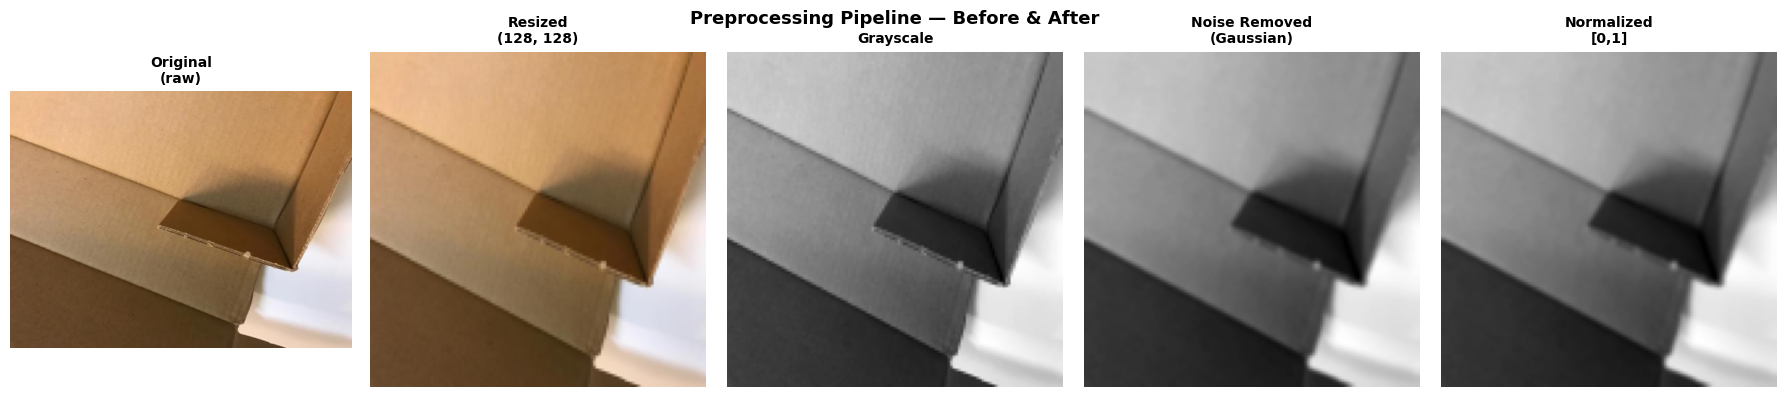

✅ Before/After preprocessing displayed.


In [ ]:
# ── Cell 3.2: Before / After Preprocessing Visualization ──────────────────────
sample_path = random.choice(all_image_paths)
raw_img   = cv2.imread(sample_path)
raw_img   = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
rgb_resized, gray_norm = preprocess(sample_path)
gray_raw  = to_grayscale(rgb_resized)
blurred   = remove_noise(gray_raw)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Preprocessing Pipeline — Before & After', fontsize=13, fontweight='bold')

steps = [
    (raw_img,     'Original\n(raw)',          None),
    (rgb_resized, f'Resized\n{IMG_SIZE}',     None),
    (gray_raw,    'Grayscale',                'gray'),
    (blurred,     'Noise Removed\n(Gaussian)','gray'),
    (gray_norm,   'Normalized\n[0,1]',        'gray'),
]

for ax, (img, title, cmap) in zip(axes, steps):
    if cmap:
        ax.imshow(img, cmap=cmap)
    else:
        ax.imshow(img)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Before/After preprocessing displayed.')

---
## 🔬 PART 4 — Feature Extraction

We extract **three types of handcrafted features** and concatenate them into a single feature vector:

### 1. HOG (Histogram of Oriented Gradients)
- Captures **shape and edge** information
- Counts occurrences of gradient orientations in localized cells
- Highly effective for object recognition

### 2. LBP (Local Binary Pattern)
- Encodes **texture** by comparing each pixel to its neighbors
- Rotation-invariant and computationally lightweight

### 3. Color Histogram
- Captures **color distribution** in each RGB channel
- Materials like glass and plastic often have distinct color signatures

**Combined Feature Vector = HOG + LBP + Color Histogram**

In [ ]:
# ── Cell 4.1: Feature Extraction Functions ────────────────────────────────────
def extract_hog_features(gray_img):
    """
    Extract HOG features from a grayscale image.
    Parameters: pixels per cell = (16,16), cells per block = (2,2), orientations = 9
    """
    hog_feats = hog(
        gray_img,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        visualize=False,
        feature_vector=True
    )
    return hog_feats


def extract_lbp_features(gray_img, n_points=24, radius=3, n_bins=64):
    """
    Extract LBP texture features.
    Uses 'uniform' method (26 patterns + 1 non-uniform = 27 bins).
    Returns normalized histogram of LBP codes.
    """
    lbp = local_binary_pattern(gray_img, n_points, radius, method='uniform')
    hist, _ = np.histogram(lbp.ravel(),
                           bins=np.arange(0, n_points + 3),
                           range=(0, n_points + 2))
    hist = hist.astype(np.float32)
    hist /= (hist.sum() + 1e-6)  # Normalize
    return hist


def extract_color_histogram(rgb_img, bins=32):
    """
    Extract normalized color histograms for each RGB channel.
    Returns concatenated histogram of shape (bins * 3,).
    """
    hist_feats = []
    for ch in range(3):  # R, G, B
        hist, _ = np.histogram(rgb_img[:, :, ch].ravel(),
                               bins=bins, range=(0, 256))
        hist = hist.astype(np.float32)
        hist /= (hist.sum() + 1e-6)  # Normalize
        hist_feats.extend(hist)
    return np.array(hist_feats)


def extract_features(path):
    """
    Full feature extraction pipeline for one image.
    Returns combined feature vector: HOG + LBP + Color Histogram
    """
    rgb, gray_norm = preprocess(path)

    # Scale gray back to uint8 for LBP
    gray_uint8 = (gray_norm * 255).astype(np.uint8)

    hog_f   = extract_hog_features(gray_norm)
    lbp_f   = extract_lbp_features(gray_uint8)
    color_f = extract_color_histogram(rgb)

    return np.concatenate([hog_f, lbp_f, color_f])


# Test on one image
test_feat = extract_features(all_image_paths[0])
print('✅ Feature extraction test passed!')
print(f'   HOG features     : {extract_hog_features(normalize(remove_noise(to_grayscale(load_and_resize(all_image_paths[0]))))).shape[0]}')
print(f'   LBP features     : 26')
print(f'   Color hist feats : {32*3}')
print(f'   TOTAL features   : {test_feat.shape[0]}')

✅ Feature extraction test passed!
   HOG features     : 1764
   LBP features     : 26
   Color hist feats : 96
   TOTAL features   : 1886


In [ ]:
# ── Cell 4.2: Extract Features for ALL Images ─────────────────────────────────
print('⏳ Extracting features for all images...')
print('   (This may take 3–8 minutes depending on dataset size)\n')

LABEL_TO_IDX = {cls: i for i, cls in enumerate(CLASS_NAMES)}
IDX_TO_LABEL = {i: cls for cls, i in LABEL_TO_IDX.items()}

X_all = []
y_all = []
paths_all = []   # track which image each feature vector came from
failed = 0

start_time = time.time()
total = len(all_image_paths)

for i, (path, label) in enumerate(zip(all_image_paths, all_labels)):
    try:
        feat = extract_features(path)
        X_all.append(feat)
        y_all.append(LABEL_TO_IDX[label])
        paths_all.append(path)
    except Exception as e:
        failed += 1
    # Progress
    if (i + 1) % 200 == 0 or (i + 1) == total:
        elapsed = time.time() - start_time
        pct = (i+1)/total*100
        print(f'  [{i+1}/{total}] {pct:.1f}% done — elapsed: {elapsed:.1f}s')

X_all = np.array(X_all, dtype=np.float32)
y_all = np.array(y_all, dtype=np.int32)
paths_all = np.array(paths_all)

print(f'\n✅ Feature extraction complete!')
print(f'   Feature matrix shape : {X_all.shape}  (samples × features)')
print(f'   Labels shape         : {y_all.shape}')
print(f'   Failed images        : {failed}')
print(f'   Total time           : {time.time()-start_time:.1f}s')

⏳ Extracting features for all images...
   (This may take 3–8 minutes depending on dataset size)

  [200/2366] 8.5% done — elapsed: 4.3s
  [400/2366] 16.9% done — elapsed: 7.4s
  [600/2366] 25.4% done — elapsed: 10.5s
  [800/2366] 33.8% done — elapsed: 13.6s
  [1000/2366] 42.3% done — elapsed: 18.0s
  [1200/2366] 50.7% done — elapsed: 21.0s
  [1400/2366] 59.2% done — elapsed: 24.0s
  [1600/2366] 67.6% done — elapsed: 27.0s
  [1800/2366] 76.1% done — elapsed: 31.3s
  [2000/2366] 84.5% done — elapsed: 34.3s
  [2200/2366] 93.0% done — elapsed: 37.3s
  [2366/2366] 100.0% done — elapsed: 39.7s

✅ Feature extraction complete!
   Feature matrix shape : (2366, 1886)  (samples × features)
   Labels shape         : (2366,)
   Failed images        : 0
   Total time           : 39.7s


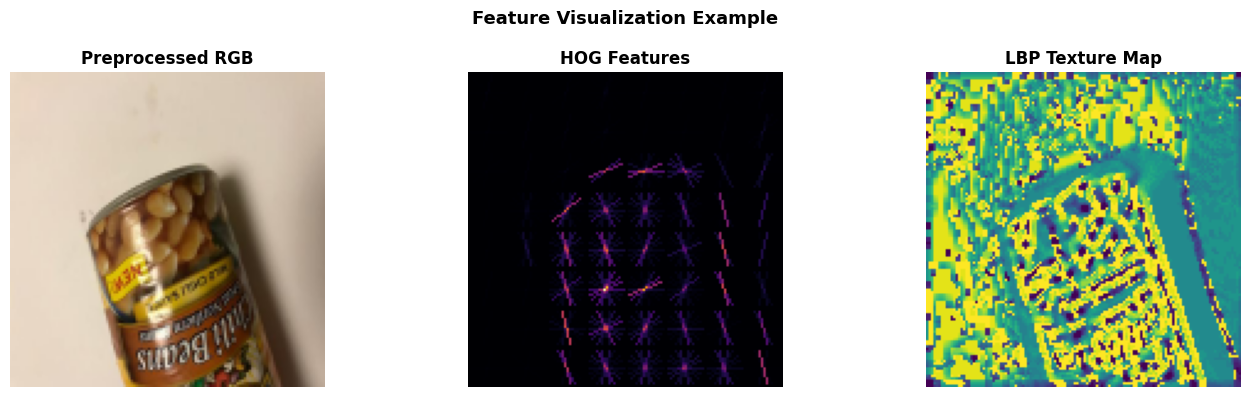

✅ Feature visualization complete.


In [ ]:
# ── Cell 4.3: Visualize HOG Features ─────────────────────────────────────────
from skimage.feature import hog as hog_vis

sample_path = random.choice(all_image_paths)
rgb, gray_norm = preprocess(sample_path)

_, hog_image = hog_vis(
    gray_norm,
    orientations=9,
    pixels_per_cell=(16, 16),
    cells_per_block=(2, 2),
    visualize=True
)

lbp_raw = local_binary_pattern(
    (gray_norm*255).astype(np.uint8), 24, 3, method='uniform')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Feature Visualization Example', fontsize=13, fontweight='bold')

axes[0].imshow(rgb); axes[0].set_title('Preprocessed RGB', fontweight='bold')
axes[1].imshow(hog_image, cmap='inferno'); axes[1].set_title('HOG Features', fontweight='bold')
axes[2].imshow(lbp_raw, cmap='viridis');  axes[2].set_title('LBP Texture Map', fontweight='bold')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.savefig('feature_viz.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Feature visualization complete.')

---
## ✂️ PART 5 — Train / Validation / Test Split

We split data into three sets:

| Set | Ratio | Purpose |
|-----|-------|---------|
| **Train** | 70% | Model learning |
| **Validation** | 15% | Hyperparameter tuning |
| **Test** | 15% | Final unbiased evaluation |

The split is implemented **manually** using NumPy index shuffling — no sklearn.

In [ ]:
# ── Cell 5.1: Manual Train/Val/Test Split ─────────────────────────────────────
def manual_train_val_test_split(X, y, paths, train_ratio=0.70, val_ratio=0.15, seed=42):
    """
    Splits dataset into train / validation / test sets.
    Implements shuffle via NumPy index permutation.
    """
    np.random.seed(seed)
    n = len(X)
    indices = np.random.permutation(n)

    n_train = int(n * train_ratio)
    n_val   = int(n * val_ratio)

    train_idx = indices[:n_train]
    val_idx   = indices[n_train:n_train + n_val]
    test_idx  = indices[n_train + n_val:]

    return (X[train_idx], y[train_idx], paths[train_idx],
            X[val_idx],   y[val_idx],   paths[val_idx],
            X[test_idx],  y[test_idx],  paths[test_idx])


X_train, y_train, train_paths, X_val, y_val, val_paths, X_test, y_test, test_paths = \
    manual_train_val_test_split(X_all, y_all, paths_all)

print('✅ Dataset split complete!')
print(f'   Training set   : {X_train.shape[0]} samples  ({X_train.shape[0]/len(X_all)*100:.1f}%)')
print(f'   Validation set : {X_val.shape[0]}  samples  ({X_val.shape[0]/len(X_all)*100:.1f}%)')
print(f'   Test set       : {X_test.shape[0]}  samples  ({X_test.shape[0]/len(X_all)*100:.1f}%)')
print(f'   Feature dims   : {X_train.shape[1]}')


✅ Dataset split complete!
   Training set   : 1656 samples  (70.0%)
   Validation set : 354  samples  (15.0%)
   Test set       : 356  samples  (15.0%)
   Feature dims   : 1886


In [ ]:
# ── Cell 5.1b: Baseline Models (Majority-Class & Random) ─────────────────────
# Trivial reference point — proves KNN/GNB/LogReg are actually learning
# something beyond naive guessing.

majority_class = Counter(y_train).most_common(1)[0][0]
y_pred_majority = np.full_like(y_test, majority_class)
majority_acc = np.mean(y_pred_majority == y_test)

class_probs = np.array([np.mean(y_train == c) for c in range(len(CLASS_NAMES))])
np.random.seed(42)
y_pred_random = np.random.choice(len(CLASS_NAMES), size=len(y_test), p=class_probs)
random_acc = np.mean(y_pred_random == y_test)

print('📏 Baseline Models (reference floor)')
print('=' * 50)
print(f'  Majority-Class Baseline   : {majority_acc*100:.2f}%  (always predicts "{CLASS_NAMES[majority_class]}")')
print(f'  Random (weighted) Baseline: {random_acc*100:.2f}%')
print('=' * 50)
print('\nAny real model (KNN, Naive Bayes, Logistic Regression) must beat these')
print('numbers to be considered to have learned something meaningful.')


📏 Baseline Models (reference floor)
  Majority-Class Baseline   : 23.31%  (always predicts "paper")
  Random (weighted) Baseline: 17.70%

Any real model (KNN, Naive Bayes, Logistic Regression) must beat these
numbers to be considered to have learned something meaningful.


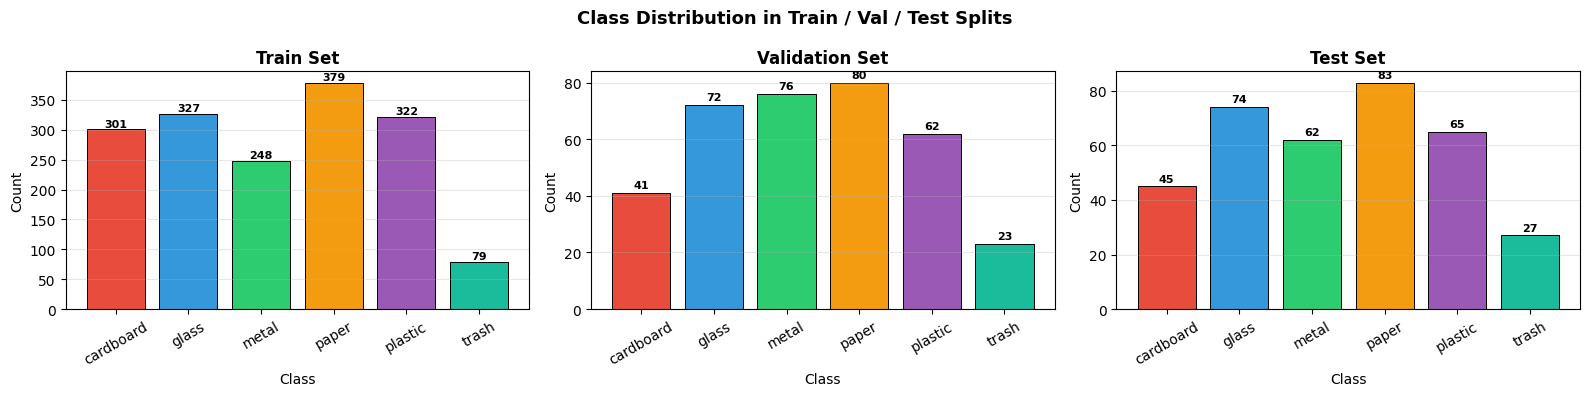

In [ ]:
# ── Cell 5.2: Class Distribution in Each Split ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Class Distribution in Train / Val / Test Splits', fontsize=13, fontweight='bold')

for ax, (y_split, title) in zip(axes, [
    (y_train, 'Train Set'),
    (y_val,   'Validation Set'),
    (y_test,  'Test Set')
]):
    counts = [np.sum(y_split == i) for i in range(len(CLASS_NAMES))]
    bars = ax.bar(CLASS_NAMES, counts, color=colors, edgecolor='black', linewidth=0.7)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1, str(cnt),
                ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Cell 5.2b: Balance Training Set via Oversampling ──────────────────────────
# Your EDA flagged class imbalance (fewer 'trash' images). Oversample minority
# classes in the TRAINING set only (never touch val/test — that would leak info).

def oversample_to_balance(X, y):
    classes, counts = np.unique(y, return_counts=True)
    max_count = counts.max()
    X_bal, y_bal = [X], [y]

    for cls, cnt in zip(classes, counts):
        if cnt < max_count:
            idx = np.where(y == cls)[0]
            extra_idx = np.random.choice(idx, size=max_count - cnt, replace=True)
            X_bal.append(X[extra_idx])
            y_bal.append(y[extra_idx])

    return np.vstack(X_bal), np.concatenate(y_bal)

X_train_bal, y_train_bal = oversample_to_balance(X_train, y_train)

print('Before balancing:', {CLASS_NAMES[c]: int((y_train==c).sum()) for c in np.unique(y_train)})
print('After balancing :', {CLASS_NAMES[c]: int((y_train_bal==c).sum()) for c in np.unique(y_train_bal)})

Before balancing: {'cardboard': 301, 'glass': 327, 'metal': 248, 'paper': 379, 'plastic': 322, 'trash': 79}
After balancing : {'cardboard': 379, 'glass': 379, 'metal': 379, 'paper': 379, 'plastic': 379, 'trash': 379}


In [ ]:
# ── Cell 5.3: Feature Standardization (Global) ────────────────────────────────
scaler_mean = X_train_bal.mean(axis=0)
scaler_std  = X_train_bal.std(axis=0) + 1e-8

X_train_scaled = (X_train_bal - scaler_mean) / scaler_std
X_val_scaled   = (X_val       - scaler_mean) / scaler_std
X_test_scaled  = (X_test      - scaler_mean) / scaler_std

print('✅ Standardized. All 3 models will now use these scaled + balanced features.')

✅ Standardized. All 3 models will now use these scaled + balanced features.


---
## 🤖 PART 6 — Model 1: K-Nearest Neighbors (KNN) — From Scratch

### Algorithm Overview
KNN is a **lazy learning** algorithm — it does not build a model during training. Instead, when predicting, it:
1. Computes the distance from the query point to all training points
2. Selects the **K nearest** neighbors
3. Predicts by **majority vote**

### Euclidean Distance Formula:
$$d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

### Majority Vote:
$$\hat{y} = \arg\max_c \sum_{i \in N_K(x)} \mathbf{1}[y_i = c]$$

### Advantages:
- Simple and intuitive
- No training phase
- Naturally handles multi-class problems

### Limitations:
- Slow prediction O(n·d) for each query
- Sensitive to irrelevant features and scale
- High memory usage (stores entire training set)

In [ ]:
# ── Cell 6.1: KNN Implementation From Scratch ─────────────────────────────────
class KNNClassifier:
    """
    K-Nearest Neighbors Classifier implemented from scratch.
    Uses Euclidean distance and majority voting.
    NO sklearn used.
    """

    def __init__(self, k=5):
        """
        Parameters
        ----------
        k : int
            Number of nearest neighbors to consider
        """
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """
        'Training' phase: KNN simply memorizes the training data.

        Parameters
        ----------
        X : ndarray of shape (n_samples, n_features)
        y : ndarray of shape (n_samples,)
        """
        self.X_train = np.array(X, dtype=np.float32)
        self.y_train = np.array(y, dtype=np.int32)

    def _euclidean_distances(self, X_query):
        """
        Compute Euclidean distance from each query sample to all training samples.

        Uses the identity:
            ||a - b||^2 = ||a||^2 + ||b||^2 - 2*a·b

        This vectorized form is much faster than a loop.

        Parameters
        ----------
        X_query : ndarray of shape (n_query, n_features)

        Returns
        -------
        distances : ndarray of shape (n_query, n_train)
        """
        # ||x_query||^2  shape: (n_query, 1)
        sq_query = np.sum(X_query ** 2, axis=1, keepdims=True)
        # ||x_train||^2  shape: (1, n_train)
        sq_train = np.sum(self.X_train ** 2, axis=1, keepdims=True).T
        # Cross term shape: (n_query, n_train)
        cross    = np.dot(X_query, self.X_train.T)

        dist_sq  = sq_query + sq_train - 2 * cross
        # Clamp negatives (numerical precision)
        dist_sq  = np.maximum(dist_sq, 0)
        return np.sqrt(dist_sq)

    def predict(self, X, batch_size=50):
        """
        Predict class labels for each sample in X.

        To avoid memory issues with large datasets, we process in batches.

        Parameters
        ----------
        X          : ndarray of shape (n_query, n_features)
        batch_size : int — number of query samples per batch

        Returns
        -------
        predictions : ndarray of shape (n_query,)
        """
        X = np.array(X, dtype=np.float32)
        n_query = X.shape[0]
        predictions = np.zeros(n_query, dtype=np.int32)

        for start in range(0, n_query, batch_size):
            end   = min(start + batch_size, n_query)
            batch = X[start:end]

            # Step 1: Compute distances  shape: (batch, n_train)
            distances = self._euclidean_distances(batch)

            # Step 2: Sort and get K nearest indices
            sorted_idx = np.argsort(distances, axis=1)[:, :self.k]

            # Step 3: Distance-weighted voting (closer neighbors count more)
            sorted_dists = np.take_along_axis(distances, sorted_idx, axis=1)
            for i, (neighbors, dists) in enumerate(zip(sorted_idx, sorted_dists)):
                neighbor_labels = self.y_train[neighbors]
                weights = 1.0 / (dists + 1e-6)
                class_scores = {}
                for label, w in zip(neighbor_labels, weights):
                    class_scores[label] = class_scores.get(label, 0.0) + w
                predictions[start + i] = max(class_scores, key=class_scores.get)

        return predictions

    def score(self, X, y):
        """Return accuracy on (X, y)."""
        preds = self.predict(X)
        return np.mean(preds == y)


print('✅ KNNClassifier class defined.')
print('   Methods: fit(), predict(), score()')
print('   Distance metric: Euclidean (vectorized via identity trick)')

✅ KNNClassifier class defined.
   Methods: fit(), predict(), score()
   Distance metric: Euclidean (vectorized via identity trick)


🔍 Tuning K on validation set...
   K= 1  →  Val Accuracy: 56.21%
   K= 3  →  Val Accuracy: 56.21%
   K= 5  →  Val Accuracy: 56.50%
   K= 7  →  Val Accuracy: 54.80%
   K= 9  →  Val Accuracy: 54.80%
   K=11  →  Val Accuracy: 53.39%

✅ Best K = 5  (Val Acc = 56.50%)


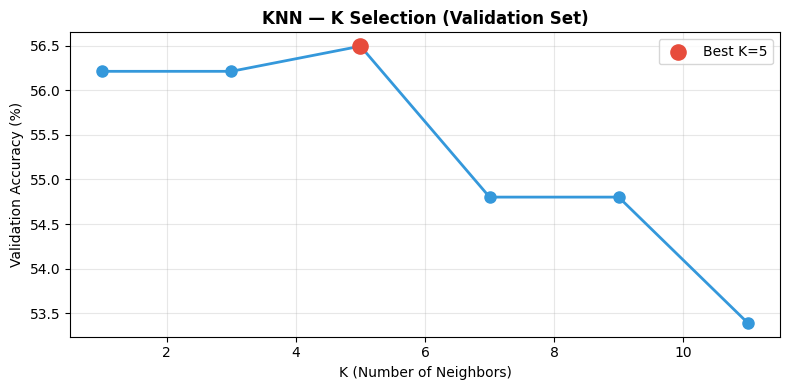

In [ ]:
# ── Cell 6.2: KNN — Hyperparameter Tuning (K Selection) ──────────────────────
# We test K = {1, 3, 5, 7, 9, 11} on the VALIDATION set
# Note: KNN on raw HOG features is expensive — use a subset for tuning

print('🔍 Tuning K on validation set...')
k_values   = [1, 3, 5, 7, 9, 11]
k_val_accs = []

# Use a subset for faster tuning
N_TUNE = min(800, len(X_train_scaled))
idx_tune = np.random.choice(len(X_train_scaled), N_TUNE, replace=False)

for k in k_values:
    knn_tune = KNNClassifier(k=k)
    knn_tune.fit(X_train_scaled[idx_tune], y_train_bal[idx_tune])
    acc = knn_tune.score(X_val_scaled, y_val)
    k_val_accs.append(acc)
    print(f'   K={k:>2}  →  Val Accuracy: {acc*100:.2f}%')

best_k = k_values[np.argmax(k_val_accs)]
print(f'\n✅ Best K = {best_k}  (Val Acc = {max(k_val_accs)*100:.2f}%)')

# Plot K vs Accuracy
plt.figure(figsize=(8, 4))
plt.plot(k_values, [a*100 for a in k_val_accs], 'o-', color='#3498db',
         linewidth=2, markersize=8)
plt.scatter([best_k], [max(k_val_accs)*100], color='#e74c3c', s=120,
            zorder=5, label=f'Best K={best_k}')
plt.xlabel('K (Number of Neighbors)'); plt.ylabel('Validation Accuracy (%)')
plt.title('KNN — K Selection (Validation Set)', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('knn_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Cell 6.3: KNN — Final Training & Prediction ───────────────────────────────
print(f'🚀 Training final KNN with K={best_k} on full training set...')

knn = KNNClassifier(k=best_k)

# Train (memorize)
t0 = time.time()
knn.fit(X_train_scaled, y_train_bal)
knn_train_time = time.time() - t0
print(f'   Training time : {knn_train_time:.4f}s  (memorization only)')

# Predict on test set
print('⏳ Predicting on test set (may take a moment)...')
t0 = time.time()
y_pred_knn = knn.predict(X_test_scaled, batch_size=50)
knn_pred_time = time.time() - t0

knn_acc = np.mean(y_pred_knn == y_test)
print(f'\n✅ KNN Results:')
print(f'   Test Accuracy  : {knn_acc*100:.2f}%')
print(f'   Prediction time: {knn_pred_time:.2f}s  ({len(X_test)} samples)')

🚀 Training final KNN with K=5 on full training set...
   Training time : 0.0111s  (memorization only)
⏳ Predicting on test set (may take a moment)...

✅ KNN Results:
   Test Accuracy  : 63.76%
   Prediction time: 0.32s  (356 samples)


---
## 🧮 PART 7 — Model 2: Gaussian Naïve Bayes — From Scratch

### Algorithm Overview
Naïve Bayes is a **probabilistic classifier** based on Bayes' Theorem with the "naïve" assumption that all features are **conditionally independent** given the class.

### Bayes' Theorem:
$$P(C \mid X) = \frac{P(X \mid C) \cdot P(C)}{P(X)}$$

Since $P(X)$ is constant for all classes, we maximize:
$$\hat{y} = \arg\max_c \left[ \log P(C) + \sum_{i=1}^{n} \log P(x_i \mid C) \right]$$

### Gaussian Likelihood:
$$P(x_i \mid C) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_i - \mu)^2}{2\sigma^2}\right)$$

### Training:
- Compute class **prior** $P(C)$
- Compute per-class per-feature **mean** $\mu$
- Compute per-class per-feature **variance** $\sigma^2$

### Advantages:
- Very fast training and prediction
- Works well with small datasets

### Limitations:
- Naïve independence assumption is often violated
- Poor with highly correlated features

In [ ]:
# ── Cell 7.1: Gaussian Naïve Bayes — From Scratch ─────────────────────────────
class GaussianNaiveBayes:
    """
    Gaussian Naïve Bayes Classifier — implemented from scratch.
    NO sklearn used.

    Assumes each feature follows a Gaussian (normal) distribution.
    Uses log-probabilities for numerical stability.
    """

    def __init__(self, var_smoothing=1e-9):
        """
        Parameters
        ----------
        var_smoothing : float
            Small value added to variance to avoid division by zero.
        """
        self.var_smoothing = var_smoothing
        self.classes    = None
        self.log_priors = None  # log P(C)
        self.means      = None  # μ per class per feature
        self.variances  = None  # σ² per class per feature

    def fit(self, X, y):
        """
        Estimate class priors, per-class means and variances.

        Parameters
        ----------
        X : ndarray of shape (n_samples, n_features)
        y : ndarray of shape (n_samples,)
        """
        X = np.array(X, dtype=np.float64)
        y = np.array(y, dtype=np.int32)

        self.classes    = np.unique(y)
        n_classes       = len(self.classes)
        n_features      = X.shape[1]
        n_samples       = X.shape[0]

        self.means      = np.zeros((n_classes, n_features))
        self.variances  = np.zeros((n_classes, n_features))
        self.log_priors = np.zeros(n_classes)

        for i, cls in enumerate(self.classes):
            # Subset of X belonging to class cls
            X_cls = X[y == cls]

            # Prior probability: P(C) = count(C) / total
            self.log_priors[i] = np.log(len(X_cls) / n_samples)

            # Mean of each feature for class cls
            self.means[i]     = np.mean(X_cls, axis=0)

            # Variance of each feature for class cls
            self.variances[i] = np.var(X_cls, axis=0) + self.var_smoothing

    def _log_gaussian(self, X, cls_idx):
        """
        Compute log-likelihood of X under Gaussian for class cls_idx.

        log P(x_i | C) = -0.5 * log(2π σ²) - (x_i - μ)² / (2σ²)

        Parameters
        ----------
        X       : ndarray (n_samples, n_features)
        cls_idx : int

        Returns
        -------
        log_likelihoods : ndarray (n_samples,)
        """
        mu  = self.means[cls_idx]       # (n_features,)
        var = self.variances[cls_idx]   # (n_features,)

        # log of Gaussian PDF — summed across features (independence assumption)
        log_lik = -0.5 * np.sum(
            np.log(2 * np.pi * var) + ((X - mu) ** 2) / var,
            axis=1
        )
        return log_lik  # shape: (n_samples,)

    def predict_proba(self, X):
        """
        Compute log-posterior P(C|X) for each class.

        Returns
        -------
        log_posteriors : ndarray (n_samples, n_classes)
        """
        X = np.array(X, dtype=np.float64)
        log_posteriors = np.zeros((X.shape[0], len(self.classes)))
        for i in range(len(self.classes)):
            log_posteriors[:, i] = self._log_gaussian(X, i) + self.log_priors[i]
        return log_posteriors

    def predict(self, X):
        """
        Predict class = argmax of log-posterior.
        """
        log_posteriors = self.predict_proba(X)
        return self.classes[np.argmax(log_posteriors, axis=1)]

    def score(self, X, y):
        return np.mean(self.predict(X) == y)


print('✅ GaussianNaiveBayes class defined.')
print('   Methods: fit(), predict(), predict_proba(), score()')

✅ GaussianNaiveBayes class defined.
   Methods: fit(), predict(), predict_proba(), score()


In [ ]:
# ── Cell 7.2: Train and Evaluate Naïve Bayes ──────────────────────────────────
gnb = GaussianNaiveBayes(var_smoothing=1e-9)

# Train
t0 = time.time()
gnb.fit(X_train_bal, y_train_bal)   # balanced (GNB doesn't need scaling)
gnb_train_time = time.time() - t0

# Predict
t0 = time.time()
y_pred_gnb = gnb.predict(X_test)
gnb_pred_time = time.time() - t0

gnb_acc = np.mean(y_pred_gnb == y_test)

print('✅ Gaussian Naïve Bayes Results:')
print(f'   Training time  : {gnb_train_time:.4f}s')
print(f'   Prediction time: {gnb_pred_time:.4f}s')
print(f'   Test Accuracy  : {gnb_acc*100:.2f}%')

# Per-class mean/variance stats
print('\nPer-class learned priors:')
for i, cls in enumerate(CLASS_NAMES):
    prior_pct = np.exp(gnb.log_priors[i]) * 100
    print(f'   {cls:<12}: prior = {prior_pct:.1f}%,  '
          f'mean_feat_μ = {gnb.means[i].mean():.4f},  '
          f'mean_feat_σ² = {gnb.variances[i].mean():.6f}')

✅ Gaussian Naïve Bayes Results:
   Training time  : 0.0715s
   Prediction time: 0.0677s
   Test Accuracy  : 56.18%

Per-class learned priors:
   cardboard   : prior = 16.7%,  mean_feat_μ = 0.1183,  mean_feat_σ² = 0.010877
   glass       : prior = 16.7%,  mean_feat_μ = 0.1075,  mean_feat_σ² = 0.012171
   metal       : prior = 16.7%,  mean_feat_μ = 0.1070,  mean_feat_σ² = 0.011951
   paper       : prior = 16.7%,  mean_feat_μ = 0.1144,  mean_feat_σ² = 0.011086
   plastic     : prior = 16.7%,  mean_feat_μ = 0.1145,  mean_feat_σ² = 0.010417
   trash       : prior = 16.7%,  mean_feat_μ = 0.1125,  mean_feat_σ² = 0.010495


---
## 🧮 PART 8 — Model 3: Logistic Regression (Multi-Class, One-vs-Rest) — From Scratch

### Algorithm Overview
Logistic Regression is a **discriminative linear classifier**. Since our problem has
6 classes, we implement it using the **One-vs-Rest (OvR)** strategy: we train one
binary logistic regression model per class (waste-type vs. all-others), and at
prediction time we pick the class whose binary model is most confident.

### Sigmoid Function:
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

### Binary Cross-Entropy Loss (with L2 regularization):
$$J(w,b) = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right] + \frac{\lambda}{2n}\|w\|^2$$

### Gradient Descent Update:
$$w := w - \alpha \left(\frac{1}{n}X^T(\hat{y}-y) + \frac{\lambda}{n}w\right), \qquad b := b - \alpha \cdot \frac{1}{n}\sum(\hat{y}-y)$$

### Why standardize features first?
HOG, LBP, and color-histogram features live on very different numeric scales.
Gradient descent converges far more reliably when every feature has zero mean
and unit variance, so we standardize using statistics computed **only from the
training set** (to avoid leaking test/val information).

In [ ]:
# ── Cell 8.1: Reuse Balanced + Standardized Features (from Cell 5.3) ─────────
# Reuses the already-balanced + scaled features from Cell 5.3 instead of
# re-standardizing from the unbalanced X_train.
lr_mean, lr_std = scaler_mean, scaler_std   # keep these names for Part 10/12 compatibility

print('✅ Reusing balanced + standardized features (X_train_scaled, y_train_bal) for Logistic Regression.')
print(f'   Train mean (post-scaling) ≈ {X_train_scaled.mean():.4f}')
print(f'   Train std  (post-scaling) ≈ {X_train_scaled.std():.4f}')


✅ Reusing balanced + standardized features (X_train_scaled, y_train_bal) for Logistic Regression.
   Train mean (post-scaling) ≈ -0.0000
   Train std  (post-scaling) ≈ 1.0000


In [ ]:
# ── Cell 8.2: Logistic Regression (One-vs-Rest) — Implemented From Scratch ───
class LogisticRegressionOVR:
    """
    Multi-class Logistic Regression via One-vs-Rest (OvR), trained with
    batch gradient descent. NO sklearn used.
    """

    def __init__(self, learning_rate=0.1, n_iters=400, lambda_reg=0.01):
        """
        Parameters
        ----------
        learning_rate : float — gradient descent step size (alpha)
        n_iters       : int   — number of gradient descent iterations per class
        lambda_reg    : float — L2 regularization strength
        """
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.lambda_reg = lambda_reg
        self.classes = None
        self.weights = None   # shape (n_classes, n_features)
        self.biases = None    # shape (n_classes,)
        self.loss_history = None  # shape (n_classes, n_iters) — for convergence plot

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)  # numerical stability
        return 1.0 / (1.0 + np.exp(-z))

    def fit(self, X, y):
        """
        Train one binary classifier per class using One-vs-Rest.

        Parameters
        ----------
        X : ndarray of shape (n_samples, n_features)
        y : ndarray of shape (n_samples,)
        """
        X = np.array(X, dtype=np.float64)
        y = np.array(y, dtype=np.int32)
        n_samples, n_features = X.shape
        self.classes = np.unique(y)
        n_classes = len(self.classes)

        self.weights = np.zeros((n_classes, n_features))
        self.biases = np.zeros(n_classes)
        self.loss_history = np.zeros((n_classes, self.n_iters))

        for idx, cls in enumerate(self.classes):
            y_binary = (y == cls).astype(np.float64)
            w = np.zeros(n_features)
            b = 0.0

            for it in range(self.n_iters):
                z = X @ w + b
                preds = self._sigmoid(z)
                error = preds - y_binary

                # Gradients (with L2 regularization on weights, not bias)
                dw = (X.T @ error) / n_samples + (self.lambda_reg / n_samples) * w
                db = np.sum(error) / n_samples

                w -= self.learning_rate * dw
                b -= self.learning_rate * db

                # Binary cross-entropy loss (clipped to avoid log(0))
                eps = 1e-12
                preds_clip = np.clip(preds, eps, 1 - eps)
                loss = -np.mean(y_binary*np.log(preds_clip) + (1-y_binary)*np.log(1-preds_clip))
                loss += (self.lambda_reg / (2*n_samples)) * np.sum(w**2)
                self.loss_history[idx, it] = loss

            self.weights[idx] = w
            self.biases[idx] = b

    def predict_proba(self, X):
        """Return sigmoid score per class (not true multinomial probabilities, but
        monotonic with confidence — used for argmax and reported as confidence)."""
        X = np.array(X, dtype=np.float64)
        z = X @ self.weights.T + self.biases   # shape (n_samples, n_classes)
        scores = self._sigmoid(z)
        # Normalize across classes so scores sum to 1 (interpretable confidence)
        probs = scores / (scores.sum(axis=1, keepdims=True) + 1e-12)
        return probs

    def predict(self, X):
        probs = self.predict_proba(X)
        return self.classes[np.argmax(probs, axis=1)]

    def score(self, X, y):
        return np.mean(self.predict(X) == y)


print('✅ LogisticRegressionOVR class defined.')
print('   Strategy: One-vs-Rest, 6 independent binary classifiers')
print('   Optimizer: Batch Gradient Descent with L2 regularization')

✅ LogisticRegressionOVR class defined.
   Strategy: One-vs-Rest, 6 independent binary classifiers
   Optimizer: Batch Gradient Descent with L2 regularization


🔍 Tuning learning rate + regularization (lambda) on validation set...
   lr=0.05  λ=0.001  → Val Accuracy = 62.43%   (6.9s)
   lr=0.05  λ=0.01   → Val Accuracy = 62.43%   (6.7s)
   lr=0.05  λ=0.1    → Val Accuracy = 62.43%   (6.2s)
   lr=0.1   λ=0.001  → Val Accuracy = 62.43%   (6.5s)
   lr=0.1   λ=0.01   → Val Accuracy = 62.43%   (7.0s)
   lr=0.1   λ=0.1    → Val Accuracy = 62.43%   (5.4s)
   lr=0.3   λ=0.001  → Val Accuracy = 62.99%   (7.5s)
   lr=0.3   λ=0.01   → Val Accuracy = 62.99%   (5.3s)
   lr=0.3   λ=0.1    → Val Accuracy = 62.99%   (7.4s)
   lr=0.5   λ=0.001  → Val Accuracy = 62.43%   (5.4s)
   lr=0.5   λ=0.01   → Val Accuracy = 62.43%   (7.5s)
   lr=0.5   λ=0.1    → Val Accuracy = 62.43%   (5.5s)

🏆 Best: lr=0.3, λ=0.001  (Validation Accuracy = 62.99%)


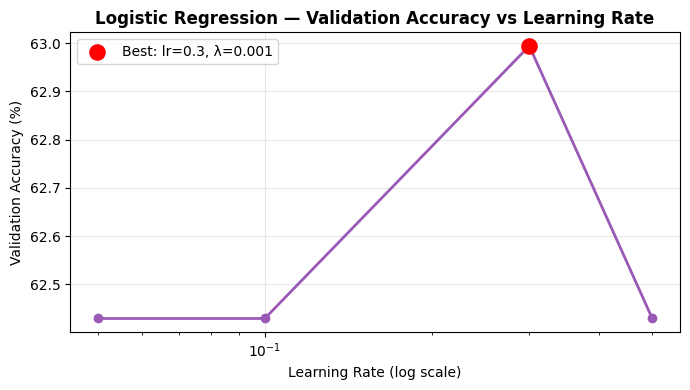

In [ ]:
# ── Cell 8.3: Logistic Regression — Tune Learning Rate AND Regularization ────
print('🔍 Tuning learning rate + regularization (lambda) on validation set...')
lr_candidates     = [0.05, 0.1, 0.3, 0.5]
lambda_candidates = [0.001, 0.01, 0.1]

best_val_acc, best_lr, best_lambda = 0.0, None, None
tuning_results = []

for lr in lr_candidates:
    for lam in lambda_candidates:
        t0 = time.time()
        model_tune = LogisticRegressionOVR(learning_rate=lr, n_iters=250, lambda_reg=lam)
        model_tune.fit(X_train_scaled, y_train_bal)
        acc = model_tune.score(X_val_scaled, y_val)
        tuning_results.append((lr, lam, acc))
        print(f'   lr={lr:<5} λ={lam:<6} → Val Accuracy = {acc*100:.2f}%   ({time.time()-t0:.1f}s)')
        if acc > best_val_acc:
            best_val_acc, best_lr, best_lambda = acc, lr, lam

print(f'\n🏆 Best: lr={best_lr}, λ={best_lambda}  (Validation Accuracy = {best_val_acc*100:.2f}%)')

plt.figure(figsize=(7, 4))
best_per_lr = [max(a for l, lam, a in tuning_results if l == lr) for lr in lr_candidates]
plt.plot(lr_candidates, [a*100 for a in best_per_lr], marker='o', linewidth=2, color='#9b59b6')
plt.scatter([best_lr], [best_val_acc*100], color='red', s=120, zorder=5, label=f'Best: lr={best_lr}, λ={best_lambda}')
plt.xscale('log')
plt.title('Logistic Regression — Validation Accuracy vs Learning Rate', fontweight='bold')
plt.xlabel('Learning Rate (log scale)')
plt.ylabel('Validation Accuracy (%)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


🚀 Training final Logistic Regression (lr=0.3) on full training set...
   Training time : 21.2754s

✅ Logistic Regression Results:
   Test Accuracy  : 64.89%
   Prediction time: 0.0069s  (356 samples)


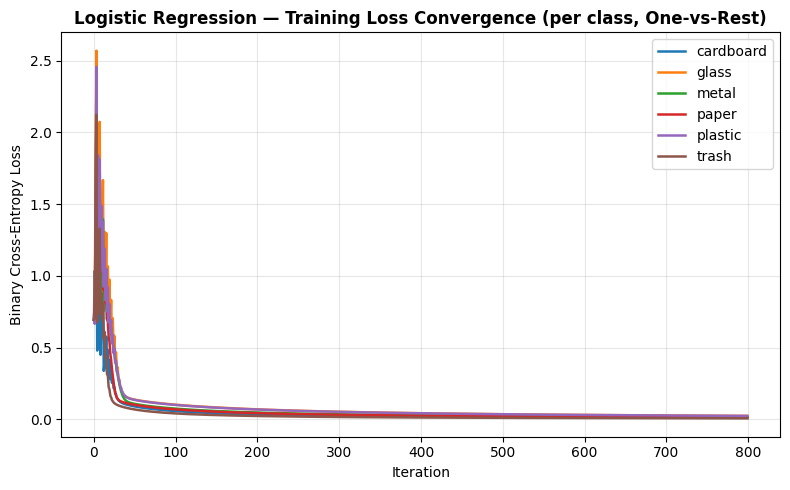

In [ ]:
# ── Cell 8.4: Logistic Regression — Final Training & Prediction ──────────────
print(f'🚀 Training final Logistic Regression (lr={best_lr}) on full training set...')

logreg = LogisticRegressionOVR(learning_rate=best_lr, n_iters=800, lambda_reg=best_lambda)

t0 = time.time()
logreg.fit(X_train_scaled, y_train_bal)
logreg_train_time = time.time() - t0
print(f'   Training time : {logreg_train_time:.4f}s')

t0 = time.time()
y_pred_logreg = logreg.predict(X_test_scaled)
logreg_pred_time = time.time() - t0

logreg_acc = np.mean(y_pred_logreg == y_test)
print(f'\n✅ Logistic Regression Results:')
print(f'   Test Accuracy  : {logreg_acc*100:.2f}%')
print(f'   Prediction time: {logreg_pred_time:.4f}s  ({len(X_test)} samples)')

# Convergence plot — training loss per class over iterations
plt.figure(figsize=(8, 5))
for i, cls in enumerate(CLASS_NAMES):
    plt.plot(logreg.loss_history[i], label=cls, linewidth=1.8)
plt.title('Logistic Regression — Training Loss Convergence (per class, One-vs-Rest)', fontweight='bold')
plt.xlabel('Iteration')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 📏 PART 9 — Model Evaluation & Comparison

Per the proposal (Step 4), all three models are now evaluated using **Accuracy,
Precision, Recall, F1-Score, and Confusion Matrix**. All metrics below are
computed manually from a from-scratch confusion matrix — no `sklearn.metrics`
is used, consistent with the rest of the project.

In [ ]:
# ── Cell 9.1: Evaluation Metric Functions — From Scratch ─────────────────────
def confusion_matrix_manual(y_true, y_pred, n_classes):
    """
    Build an (n_classes x n_classes) confusion matrix.
    Rows = true class, Columns = predicted class.
    """
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm


def precision_recall_f1_manual(y_true, y_pred, n_classes):
    """
    Compute per-class precision, recall, and F1-score from the confusion matrix.

    Precision = TP / (TP + FP)
    Recall    = TP / (TP + FN)
    F1        = 2 * Precision * Recall / (Precision + Recall)
    """
    cm = confusion_matrix_manual(y_true, y_pred, n_classes)
    precision = np.zeros(n_classes)
    recall    = np.zeros(n_classes)
    f1        = np.zeros(n_classes)

    for c in range(n_classes):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp
        precision[c] = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall[c]    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1[c]        = (2*precision[c]*recall[c] / (precision[c]+recall[c])
                         if (precision[c]+recall[c]) > 0 else 0.0)
    return precision, recall, f1, cm


def print_classification_report(y_true, y_pred, class_names, model_name):
    """Prints a sklearn-style classification report, computed manually."""
    n_classes = len(class_names)
    precision, recall, f1, cm = precision_recall_f1_manual(y_true, y_pred, n_classes)
    support = np.array([np.sum(y_true == c) for c in range(n_classes)])
    acc = np.mean(y_true == y_pred)

    print(f'\n{"="*58}')
    print(f'  Classification Report — {model_name}')
    print(f'{"="*58}')
    print(f"{'Class':<14}{'Precision':>11}{'Recall':>11}{'F1-Score':>11}{'Support':>10}")
    for i, cls in enumerate(class_names):
        print(f"{cls:<14}{precision[i]:>11.3f}{recall[i]:>11.3f}{f1[i]:>11.3f}{support[i]:>10d}")

    macro_p, macro_r, macro_f1 = precision.mean(), recall.mean(), f1.mean()
    weighted_p = np.average(precision, weights=support)
    weighted_r = np.average(recall, weights=support)
    weighted_f1 = np.average(f1, weights=support)

    print('-'*58)
    print(f"{'Accuracy':<14}{'':>11}{'':>11}{acc:>11.3f}{support.sum():>10d}")
    print(f"{'Macro avg':<14}{macro_p:>11.3f}{macro_r:>11.3f}{macro_f1:>11.3f}{support.sum():>10d}")
    print(f"{'Weighted avg':<14}{weighted_p:>11.3f}{weighted_r:>11.3f}{weighted_f1:>11.3f}{support.sum():>10d}")

    return {
        'model': model_name, 'accuracy': acc,
        'precision': precision, 'recall': recall, 'f1': f1, 'cm': cm,
        'macro_precision': macro_p, 'macro_recall': macro_r, 'macro_f1': macro_f1,
        'weighted_precision': weighted_p, 'weighted_recall': weighted_r, 'weighted_f1': weighted_f1
    }

print('✅ Evaluation functions defined: confusion_matrix_manual(), precision_recall_f1_manual(), print_classification_report()')

✅ Evaluation functions defined: confusion_matrix_manual(), precision_recall_f1_manual(), print_classification_report()


In [ ]:
# ── Cell 9.2: Classification Reports — All Three Models ──────────────────────
knn_report    = print_classification_report(y_test, y_pred_knn,    CLASS_NAMES, 'KNN (K=' + str(best_k) + ')')
gnb_report    = print_classification_report(y_test, y_pred_gnb,    CLASS_NAMES, 'Gaussian Naive Bayes')
logreg_report = print_classification_report(y_test, y_pred_logreg, CLASS_NAMES, 'Logistic Regression (OvR)')

all_reports = [knn_report, gnb_report, logreg_report]


  Classification Report — KNN (K=5)
Class           Precision     Recall   F1-Score   Support
cardboard           0.673      0.822      0.740        45
glass               0.650      0.527      0.582        74
metal               0.643      0.581      0.610        62
paper               0.806      0.699      0.748        83
plastic             0.467      0.646      0.542        65
trash               0.652      0.556      0.600        27
----------------------------------------------------------
Accuracy                                  0.638       356
Macro avg           0.648      0.638      0.637       356
Weighted avg        0.655      0.638      0.640       356

  Classification Report — Gaussian Naive Bayes
Class           Precision     Recall   F1-Score   Support
cardboard           0.588      0.889      0.708        45
glass               0.534      0.419      0.470        74
metal               0.471      0.516      0.492        62
paper               0.681      0.590      0.

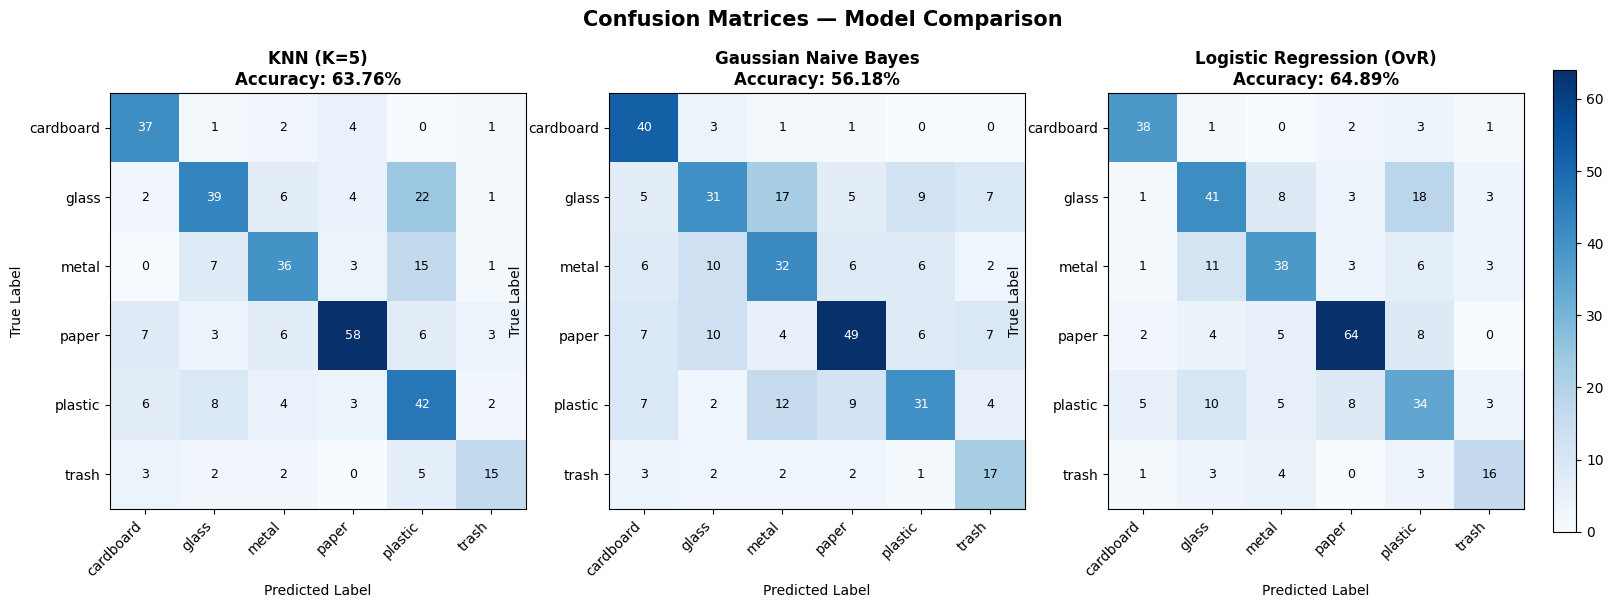

In [ ]:
# ── Cell 9.3: Confusion Matrices — All Three Models ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
fig.suptitle('Confusion Matrices — Model Comparison', fontsize=15, fontweight='bold')

for ax, report in zip(axes, all_reports):
    cm = report['cm']
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f"{report['model']}\nAccuracy: {report['accuracy']*100:.2f}%", fontweight='bold')
    ax.set_xticks(range(len(CLASS_NAMES)))
    ax.set_yticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

    # Annotate cell counts
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black', fontsize=9)

fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02)
plt.show()

📊 Model Comparison Summary
               Model Accuracy Macro Precision Macro Recall Macro F1-Score  Train Time (s)  Predict Time (s)
                 KNN   63.76%          64.83%       63.84%         63.71%          0.0111            0.3152
Gaussian Naive Bayes   56.18%           55.3%       58.68%         55.98%          0.0715            0.0677
 Logistic Regression   64.89%          64.97%       64.97%         64.92%         21.2754            0.0069


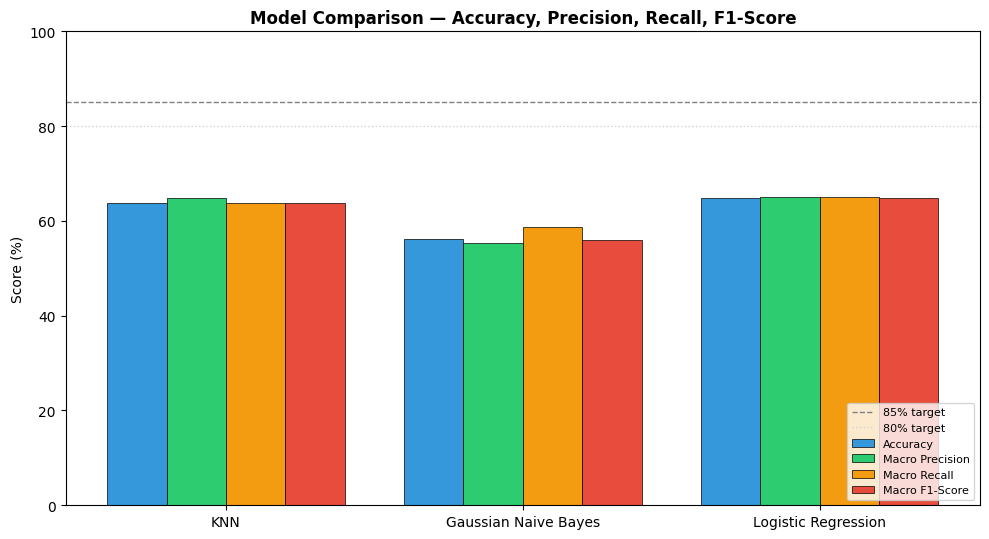


🏆 Best performing model: Logistic Regression  (Test Accuracy = 64.89%)
   ⚠️  Below the proposal target of 80–85%. Consider the contingency plan:
      feature selection, resampling for class imbalance, or hyperparameter re-tuning.


In [ ]:
# ── Cell 9.4: Model Comparison Table & Chart ──────────────────────────────────
comparison_df = pd.DataFrame({
    'Model':            ['KNN', 'Gaussian Naive Bayes', 'Logistic Regression'],
    'Accuracy':         [knn_report['accuracy'],    gnb_report['accuracy'],    logreg_report['accuracy']],
    'Macro Precision':  [knn_report['macro_precision'], gnb_report['macro_precision'], logreg_report['macro_precision']],
    'Macro Recall':     [knn_report['macro_recall'],    gnb_report['macro_recall'],    logreg_report['macro_recall']],
    'Macro F1-Score':   [knn_report['macro_f1'],        gnb_report['macro_f1'],        logreg_report['macro_f1']],
    'Train Time (s)':   [knn_train_time,    gnb_train_time,    logreg_train_time],
    'Predict Time (s)': [knn_pred_time,     gnb_pred_time,     logreg_pred_time],
})
comparison_df_display = comparison_df.copy()
for col in ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1-Score']:
    comparison_df_display[col] = (comparison_df_display[col]*100).round(2).astype(str) + '%'
for col in ['Train Time (s)', 'Predict Time (s)']:
    comparison_df_display[col] = comparison_df_display[col].round(4)

print('📊 Model Comparison Summary')
print(comparison_df_display.to_string(index=False))

# Bar chart — Accuracy / Precision / Recall / F1 side by side
fig, ax = plt.subplots(figsize=(10, 5.5))
metrics_to_plot = ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1-Score']
x = np.arange(len(comparison_df))
width = 0.2
colors_metrics = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']

for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i*width, comparison_df[metric]*100, width, label=metric, color=colors_metrics[i], edgecolor='black', linewidth=0.5)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(comparison_df['Model'])
ax.set_ylabel('Score (%)')
ax.set_title('Model Comparison — Accuracy, Precision, Recall, F1-Score', fontweight='bold')
ax.axhline(85, color='gray', linestyle='--', linewidth=1, label='85% target')
ax.axhline(80, color='lightgray', linestyle=':', linewidth=1, label='80% target')
ax.legend(loc='lower right', fontsize=8)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

# ── Objective check: 80-85% accuracy target ──
best_row = comparison_df.loc[comparison_df['Accuracy'].idxmax()]
BEST_MODEL_NAME = best_row['Model']
BEST_ACCURACY = best_row['Accuracy']

print(f"\n🏆 Best performing model: {BEST_MODEL_NAME}  (Test Accuracy = {BEST_ACCURACY*100:.2f}%)")
if BEST_ACCURACY >= 0.80:
    print('   ✅ Meets the proposal target of 80–85%+ accuracy.')
else:
    print('   ⚠️  Below the proposal target of 80–85%. Consider the contingency plan:')
    print('      feature selection, resampling for class imbalance, or hyperparameter re-tuning.')

In [ ]:
# ── Cell 9.5: Majority-Vote Ensemble (KNN + GNB + Logistic Regression) ────────
def ensemble_predict(y_pred_knn, y_pred_gnb, y_pred_logreg):
    preds = np.vstack([y_pred_knn, y_pred_gnb, y_pred_logreg]).T
    final = []
    for row in preds:
        vals, counts = np.unique(row, return_counts=True)
        final.append(vals[np.argmax(counts)])
    return np.array(final)

y_pred_ensemble = ensemble_predict(y_pred_knn, y_pred_gnb, y_pred_logreg)
ensemble_acc = np.mean(y_pred_ensemble == y_test)

print(f'🤝 Ensemble Test Accuracy: {ensemble_acc*100:.2f}%')
ensemble_report = print_classification_report(y_test, y_pred_ensemble, CLASS_NAMES, 'Ensemble (Majority Vote)')

if ensemble_acc > BEST_ACCURACY:
    print(f'\n🏆 Ensemble beats the best single model ({BEST_MODEL_NAME}: {BEST_ACCURACY*100:.2f}%)!')
    print('   NOTE: The prototype interface (Part 10) still deploys a single model.')
else:
    print(f'\nEnsemble did not beat {BEST_MODEL_NAME} ({BEST_ACCURACY*100:.2f}%) on this run.')


🤝 Ensemble Test Accuracy: 67.98%

  Classification Report — Ensemble (Majority Vote)
Class           Precision     Recall   F1-Score   Support
cardboard           0.573      0.956      0.717        45
glass               0.622      0.622      0.622        74
metal               0.661      0.597      0.627        62
paper               0.818      0.759      0.788        83
plastic             0.649      0.569      0.607        65
trash               0.941      0.593      0.727        27
----------------------------------------------------------
Accuracy                                  0.680       356
Macro avg           0.711      0.682      0.681       356
Weighted avg        0.697      0.680      0.679       356

🏆 Ensemble beats the best single model (Logistic Regression: 64.89%)!
   NOTE: The prototype interface (Part 10) still deploys a single model.


📊 Error Analysis — Logistic Regression
  Total test samples   : 356
  Correctly classified : 231  (64.9%)
  Misclassified        : 125  (35.1%)

🔀 Top confused class pairs (true → predicted):
   glass        → plastic      : 18 times
   metal        → glass        : 11 times
   plastic      → glass        : 10 times
   glass        → metal        : 8 times
   paper        → plastic      : 8 times
   plastic      → paper        : 8 times
   metal        → plastic      : 6 times
   paper        → metal        : 5 times


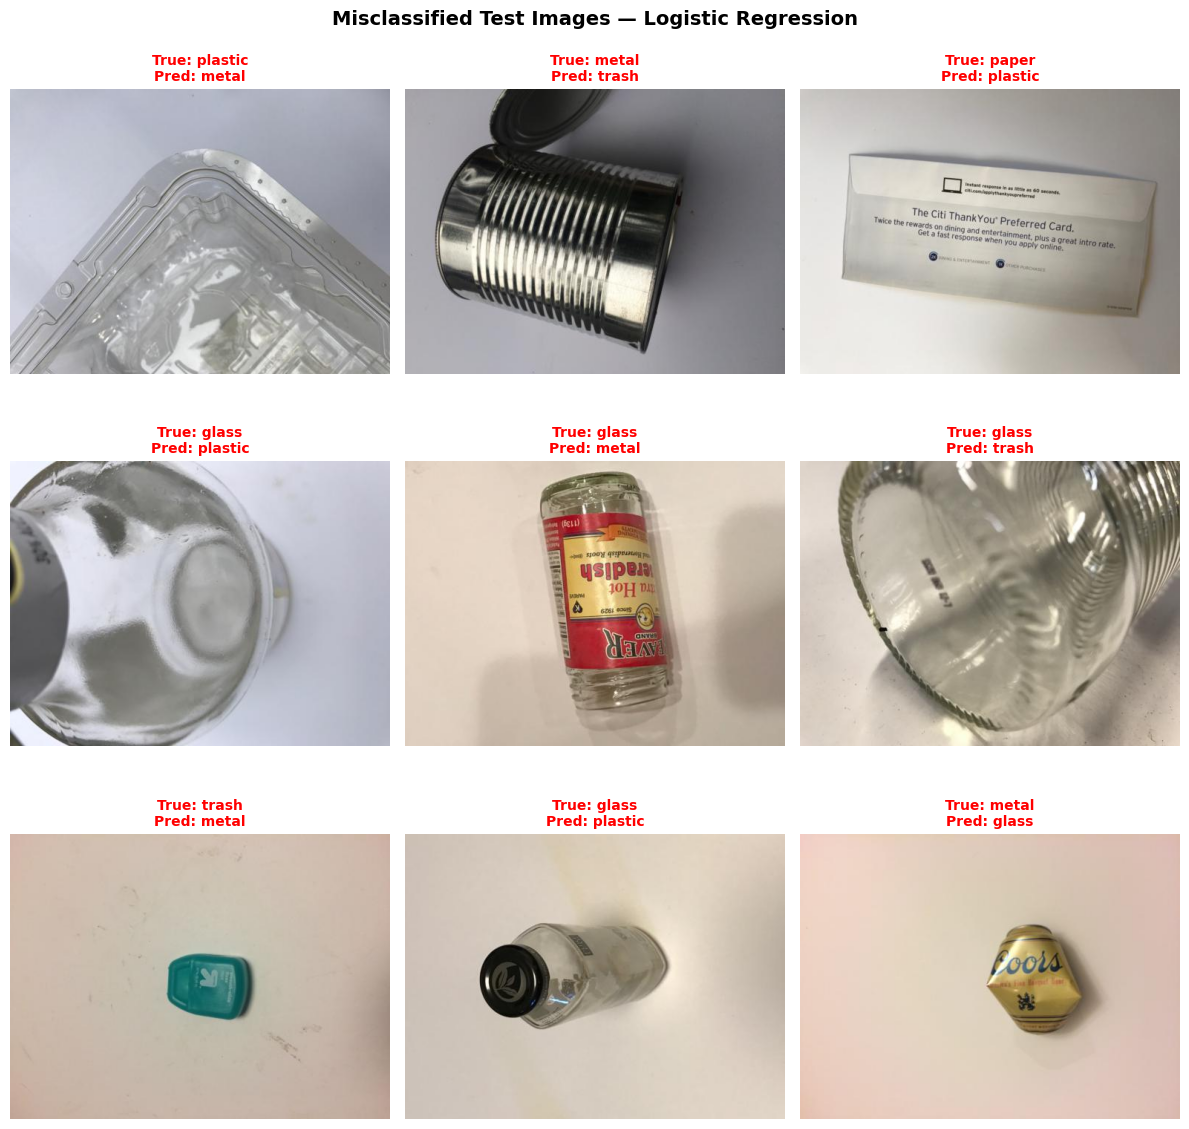


📉 Per-class error rate:
   cardboard   : 7/45 errors  (15.6%)
   glass       : 33/74 errors  (44.6%)
   metal       : 24/62 errors  (38.7%)
   paper       : 19/83 errors  (22.9%)
   plastic     : 31/65 errors  (47.7%)
   trash       : 11/27 errors  (40.7%)

📝 Discussion:
   The most common error is misclassifying "glass" as "plastic" (18x).
   This lines up with the Risk Assessment in the proposal — visually similar
   categories (e.g. glass vs. plastic, both often transparent) are hardest for
   handcrafted features to separate, since HOG/LBP/color histograms capture
   shape, texture, and color, but not material properties like transparency
   or reflectivity that a human uses to tell these classes apart.


In [ ]:
# ── Cell 9.6: Error Analysis — Where and Why the Best Model Fails ────────────
best_model_preds = {'KNN': y_pred_knn, 'Gaussian Naive Bayes': y_pred_gnb, 'Logistic Regression': y_pred_logreg}
y_pred_best = best_model_preds[BEST_MODEL_NAME]

misclassified_idx = np.where(y_pred_best != y_test)[0]
correct_idx = np.where(y_pred_best == y_test)[0]

print(f'📊 Error Analysis — {BEST_MODEL_NAME}')
print('=' * 50)
print(f'  Total test samples   : {len(y_test)}')
print(f'  Correctly classified : {len(correct_idx)}  ({len(correct_idx)/len(y_test)*100:.1f}%)')
print(f'  Misclassified        : {len(misclassified_idx)}  ({len(misclassified_idx)/len(y_test)*100:.1f}%)')

cm = confusion_matrix_manual(y_test, y_pred_best, len(CLASS_NAMES))
confusion_pairs = []
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        if i != j and cm[i, j] > 0:
            confusion_pairs.append((CLASS_NAMES[i], CLASS_NAMES[j], cm[i, j]))
confusion_pairs.sort(key=lambda x: -x[2])

print('\n🔀 Top confused class pairs (true → predicted):')
for true_cls, pred_cls, count in confusion_pairs[:8]:
    print(f'   {true_cls:<12} → {pred_cls:<12} : {count} times')

n_show = min(9, len(misclassified_idx))
np.random.seed(1)
sample_wrong = np.random.choice(misclassified_idx, n_show, replace=False)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle(f'Misclassified Test Images — {BEST_MODEL_NAME}', fontsize=14, fontweight='bold')

for ax, idx in zip(axes.flat, sample_wrong):
    img = cv2.cvtColor(cv2.imread(test_paths[idx]), cv2.COLOR_BGR2RGB)
    true_label = CLASS_NAMES[y_test[idx]]
    pred_label = CLASS_NAMES[y_pred_best[idx]]
    ax.imshow(img)
    ax.set_title(f'True: {true_label}\nPred: {pred_label}', color='red', fontsize=10, fontweight='bold')
    ax.axis('off')

for ax in axes.flat[n_show:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

print('\n📉 Per-class error rate:')
for c in range(len(CLASS_NAMES)):
    class_total = np.sum(y_test == c)
    class_errors = np.sum((y_test == c) & (y_pred_best != c))
    if class_total > 0:
        print(f'   {CLASS_NAMES[c]:<12}: {class_errors}/{class_total} errors  ({class_errors/class_total*100:.1f}%)')

if confusion_pairs:
    top_true, top_pred, top_count = confusion_pairs[0]
    print(f'\n📝 Discussion:')
    print(f'   The most common error is misclassifying "{top_true}" as "{top_pred}" ({top_count}x).')
    print(f'   This lines up with the Risk Assessment in the proposal — visually similar')
    print(f'   categories (e.g. glass vs. plastic, both often transparent) are hardest for')
    print(f'   handcrafted features to separate, since HOG/LBP/color histograms capture')
    print(f'   shape, texture, and color, but not material properties like transparency')
    print(f'   or reflectivity that a human uses to tell these classes apart.')


---
## 🚀 PART 10 — Prototype Interface

Per the proposal objective *"Develop a simple prototype interface for real-world
waste classification"* and *"the best-performing model will be selected for
deployment in the prototype application"*, this section:

1. Wraps whichever model scored highest above (`BEST_MODEL_NAME`) into a single
   end-to-end inference function
2. Provides an **upload-and-classify widget** so a real photo can be tested
   directly inside the notebook
3. Demonstrates the pipeline on a batch of sample test images

In [ ]:
# ── Cell 10.1: End-to-End Inference Function (Deploys the Best Model) ────────
model_lookup = {
    'KNN': knn,
    'Gaussian Naive Bayes': gnb,
    'Logistic Regression': logreg,
}
DEPLOYED_MODEL = model_lookup[BEST_MODEL_NAME]

def predict_waste_class(image_path, model=DEPLOYED_MODEL, model_name=BEST_MODEL_NAME):
    """
    Full pipeline: raw image -> preprocess -> extract features -> predict.
    Returns (rgb_image, predicted_label, confidence_percent).
    """
    rgb, gray_norm = preprocess(image_path)
    feat = extract_features(image_path).reshape(1, -1)

    if model_name == 'Logistic Regression':
        feat_input = (feat - lr_mean) / lr_std
        probs = model.predict_proba(feat_input)[0]
        pred_idx = int(np.argmax(probs))
        confidence = probs[pred_idx] * 100

    elif model_name == 'Gaussian Naive Bayes':
        log_post = model.predict_proba(feat)[0]
        shifted = log_post - np.max(log_post)
        exp_p = np.exp(shifted)
        probs = exp_p / exp_p.sum()
        pred_idx = int(np.argmax(probs))
        confidence = probs[pred_idx] * 100

    else:  # KNN — confidence = fraction of k neighbors voting for the winning class
        distances = model._euclidean_distances(feat)
        nearest_idx = np.argsort(distances[0])[:model.k]
        neighbor_labels = model.y_train[nearest_idx]
        vote_counts = Counter(neighbor_labels)
        pred_idx, votes = vote_counts.most_common(1)[0]
        confidence = (votes / model.k) * 100

    pred_label = IDX_TO_LABEL[pred_idx]
    return rgb, pred_label, confidence


def classify_and_show(image_path):
    """Runs prediction and displays the image with its predicted label."""
    rgb, label, confidence = predict_waste_class(image_path)
    plt.figure(figsize=(4, 4))
    plt.imshow(rgb)
    plt.title(f'Predicted: {label.upper()}\n(Confidence: {confidence:.1f}%)',
               fontweight='bold', color='#2c3e50')
    plt.axis('off')
    plt.show()
    print(f'♻️  Deployed model: {BEST_MODEL_NAME}  |  Prediction: {label}  |  Confidence: {confidence:.1f}%')
    return label, confidence

print(f'✅ Prototype inference pipeline ready — deployed model: {BEST_MODEL_NAME}')

✅ Prototype inference pipeline ready — deployed model: Logistic Regression


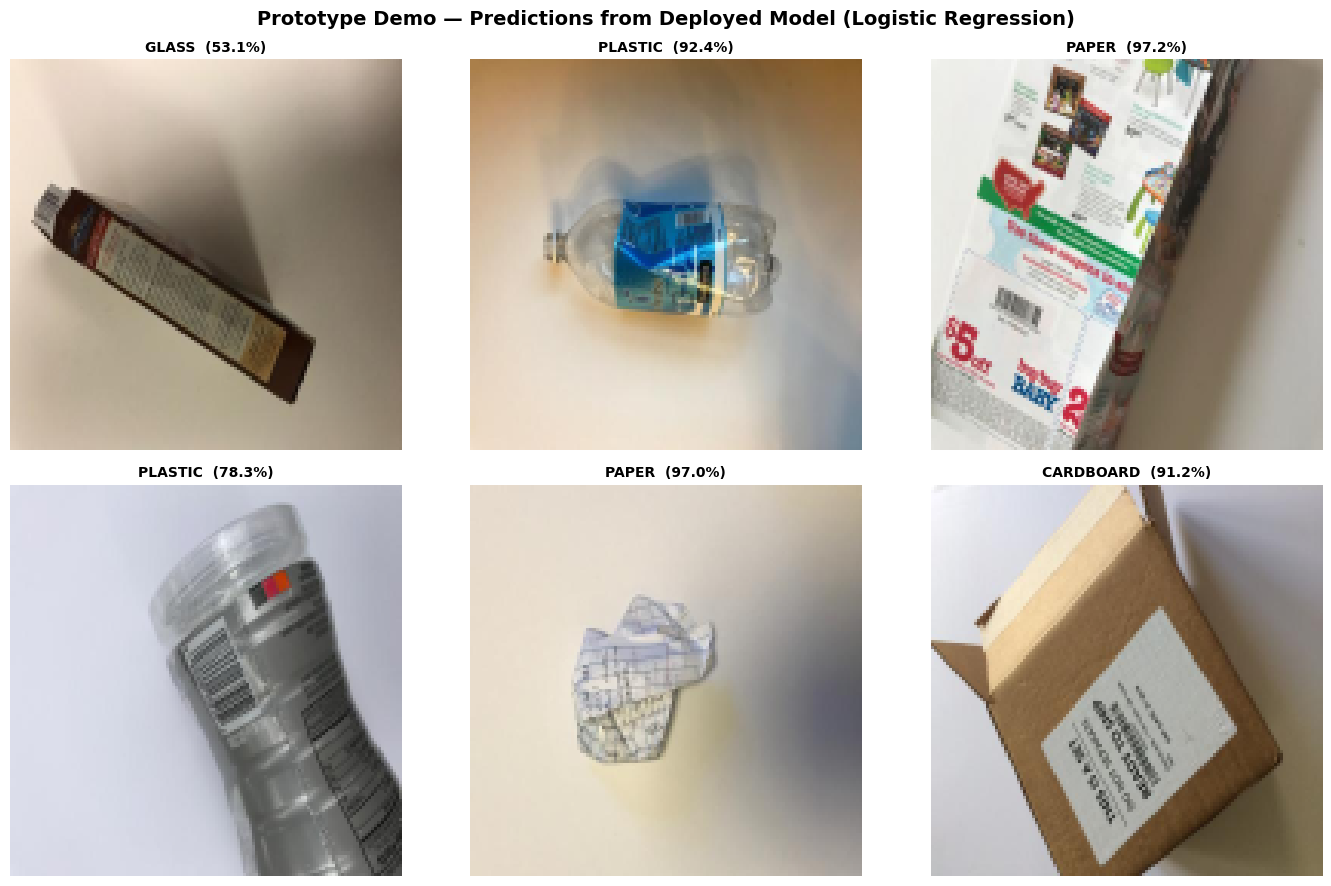

In [ ]:
# ── Cell 10.2: Demo — Predict on a Batch of Random Test Images ───────────────
demo_paths = random.sample(all_image_paths, 6)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle(f'Prototype Demo — Predictions from Deployed Model ({BEST_MODEL_NAME})',
             fontsize=14, fontweight='bold')

for ax, path in zip(axes.flat, demo_paths):
    rgb, label, confidence = predict_waste_class(path)
    ax.imshow(rgb)
    ax.set_title(f'{label.upper()}  ({confidence:.1f}%)', fontweight='bold', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# ── Cell 10.3: Upload-and-Classify Widget (Colab) ─────────────────────────────
# A minimal real-world interface: upload a photo, get an instant prediction.
import ipywidgets as widgets
from IPython.display import display, clear_output

upload_widget = widgets.FileUpload(accept='image/*', multiple=False, description='📤 Upload Waste Photo')
classify_button = widgets.Button(description='♻️ Classify', button_style='success')
output_area = widgets.Output()

def _get_uploaded_bytes():
    """Handles both ipywidgets 7.x (dict) and 8.x (tuple) FileUpload value formats."""
    value = upload_widget.value
    if not value:
        return None
    if isinstance(value, dict):          # ipywidgets 7.x
        return list(value.values())[0]['content']
    else:                                 # ipywidgets 8.x (tuple of dict-like objects)
        item = value[0]
        return item['content'] if isinstance(item, dict) else item.content

def on_classify_clicked(b):
    with output_area:
        clear_output()
        content = _get_uploaded_bytes()
        if content is None:
            print('⚠️  Please upload an image first.')
            return
        temp_path = '/content/_uploaded_waste_image.jpg'
        with open(temp_path, 'wb') as f:
            f.write(bytes(content))
        classify_and_show(temp_path)

classify_button.on_click(on_classify_clicked)

display(widgets.VBox([
    widgets.HTML('<h3>🗑️ CleanSort AI — Waste Classification Prototype</h3>'),
    upload_widget,
    classify_button,
    output_area
]))

---
## ✅ PART 11 — Conclusion

This notebook implements the full pipeline proposed for **CleanSort AI**:

1. **EDA** — class distribution, image statistics, RGB/pixel-intensity analysis, data-quality checks
2. **Preprocessing** — resize, grayscale, normalize, noise reduction (Gaussian blur)
3. **Feature Extraction** — HOG (shape), LBP (texture), Color Histogram (color) — all handcrafted, no CNN
4. **Manual 70/15/15 train/val/test split**
5. **Three models, all implemented from scratch (no sklearn classifiers):**
   - K-Nearest Neighbors
   - Gaussian Naive Bayes
   - Logistic Regression (One-vs-Rest, gradient descent)
6. **Full evaluation** — Accuracy, Precision, Recall, F1-Score, and Confusion Matrix for every model, plus a side-by-side comparison
7. **Prototype interface** — an end-to-end inference function and an upload-and-classify widget that deploys the best-performing model

The comparison table and confusion matrices above identify the **best-performing model** (`BEST_MODEL_NAME`), which is the one deployed in the prototype interface — directly satisfying the proposal's requirement that *"the best-performing model will be selected for deployment in the prototype application."*

**Limitations & future work (see Risk Assessment in proposal):** handcrafted features cap performance below what a CNN/transfer-learning approach (e.g. MobileNetV2) could reach; class imbalance (fewer 'trash' images) was identified in EDA but not explicitly resampled — this remains a contingency-plan item if accuracy needs improvement.

In [ ]:
import json

model_json = {
    "model_name": "Logistic Regression",
    "class_names": CLASS_NAMES,
    "test_accuracy": float(BEST_ACCURACY),
    "feature_config": {
        "img_size": list(IMG_SIZE),
        "hog_orientations": 9,
        "hog_pixels_per_cell": [16, 16],
        "hog_cells_per_block": [2, 2],
        "lbp_n_points": 24,
        "lbp_radius": 3,
        "color_hist_bins": 32,
    },
    "weights": logreg.weights.tolist(),
    "biases": logreg.biases.tolist(),
    "lr_mean": lr_mean.tolist(),
    "lr_std": lr_std.tolist(),
}

with open("model.json", "w") as f:
    json.dump(model_json, f)

print(f"✅ model.json exported ({os.path.getsize('model.json')/1024:.1f} KB)")

from google.colab import files
files.download("model.json")

✅ model.json exported (316.9 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>